# Download & Import Resources

In [ ]:
!pip install pmdarima
!pip install tensorflow
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.6 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten, Conv1D, Input, GRU
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from pmdarima import auto_arima
from sklearn.linear_model import LinearRegression
from pmdarima import ARIMA
from tensorflow.keras.callbacks import EarlyStopping
import pywt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import random
import itertools
import time

# Load the target dataset

In [ ]:
path = kagglehub.dataset_download("ivivan/real-time-water-quality-data")

print("Path to dataset files:", path, "\n")

file_names = os.listdir(path)

print("Files in the dataset directory:")
for file_name in file_names:
    print(file_name)

100%|██████████| 2.84M/2.84M [00:00<00:00, 71.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ivivan/real-time-water-quality-data/versions/2 

Files in the dataset directory:
Tully_River_Tully_Gorge_National_Park_joined.csv
Johnstone_river_coquette_point_joined.csv
sandy_ck_sorbellos_road_joined.csv
Plane_ck_sucrogen_joined.csv
Mulgrave_river_deeral_joined.csv
Pioneer_Dumbleton_joined.csv
Tully_river_euramo_joined.csv
Johnstone_river_innisfail_joined.csv
Proserpine_river_glen_isla_joined.csv
russell_river_east_russell_joined.csv
sandy_ck_homebush_joined.csv


In [ ]:
dfs = {}

for file_name in file_names:
  file_path = os.path.join(path, file_name)
  try:
      df = pd.read_csv(file_path)
      if len(df.columns) == 9:
        if "Timestamp" in df.columns:
          df['Timestamp'] = pd.to_datetime(df['Timestamp'])
          df.set_index('Timestamp', inplace=True)
          dfs[file_name] = df
      print(f"\n--- Sample from {file_name} ---")
      display(df.head())
  except Exception as e:
      print(f"Could not read {file_name}: {e}")

print("\nLoaded dataframes:")
for file_name, df in dfs.items():
    print(f"{file_name}: {df.shape}")


--- Sample from Tully_River_Tully_Gorge_National_Park_joined.csv ---


,Timestamp,NO3,Level,Dayofweek,Month
0,2019-03-27T16:00:00,0.015,3.502,2,3
1,2019-03-27T17:00:00,NaN,3.496,2,3
2,2019-03-27T18:00:00,NaN,3.495,2,3
3,2019-03-27T19:00:00,NaN,3.496,2,3
4,2019-03-27T20:00:00,0.016,3.489,2,3



--- Sample from Johnstone_river_coquette_point_joined.csv ---


,Timestamp,Conductivity,NO3,Temp,Turbidity,Dayofweek,Month
0,2017-05-11T14:00:00,13502.10,NaN,NaN,12.79,3,5
1,2017-05-11T15:00:00,10304.00,NaN,NaN,11.93,3,5
2,2017-05-11T16:00:00,5588.08,NaN,NaN,10.34,3,5
3,2017-05-11T17:00:00,13937.00,NaN,NaN,24.02,3,5
4,2017-05-11T18:00:00,44761.40,NaN,NaN,18.46,3,5



--- Sample from sandy_ck_sorbellos_road_joined.csv ---


...


--- Sample from russell_river_east_russell_joined.csv ---


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2016-12-08 12:00:00,-65.325500,12192.0,NaN,NaN,11.2,NaN,3,12
2016-12-08 13:00:00,-100.236500,NaN,NaN,NaN,NaN,NaN,3,12
2016-12-08 14:00:00,-68.786167,17977.0,NaN,NaN,3.4,NaN,3,12
2016-12-08 15:00:00,-75.861500,NaN,NaN,NaN,NaN,NaN,3,12
2016-12-08 16:00:00,-32.543000,31072.0,NaN,NaN,5.2,NaN,3,12



--- Sample from sandy_ck_homebush_joined.csv ---


,Conductivity,NO3,Q,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2016-12-05 18:00:00,486.0,NaN,NaN,29.05,5.7,0.474,0,12
2016-12-05 19:00:00,NaN,NaN,NaN,NaN,NaN,0.473,0,12
2016-12-05 20:00:00,485.0,NaN,NaN,28.36,7.7,0.474,0,12
2016-12-05 21:00:00,485.0,NaN,NaN,28.08,2.7,0.475,0,12
2016-12-05 22:00:00,NaN,NaN,NaN,NaN,NaN,0.474,0,12



Loaded dataframes:
sandy_ck_sorbellos_road_joined.csv: (11718, 8)
Plane_ck_sucrogen_joined.csv: (21518, 8)
Mulgrave_river_deeral_joined.csv: (29051, 8)
Tully_river_euramo_joined.csv: (28448, 8)
Proserpine_river_glen_isla_joined.csv: (28857, 8)
russell_river_east_russell_joined.csv: (29052, 8)
sandy_ck_homebush_joined.csv: (35832, 8)


# EDA

## Check Seasonality

<Axes: xlabel='Timestamp'>

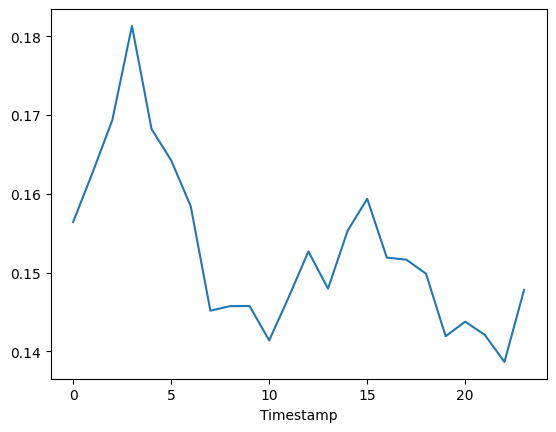

In [ ]:
df_inspect = dfs["Mulgrave_river_deeral_joined.csv"].copy()

df_clean = df_inspect.dropna(subset=["NO3"])

df_clean.groupby(df_clean.index.hour)["NO3"].mean().plot()

<Axes: xlabel='Timestamp'>

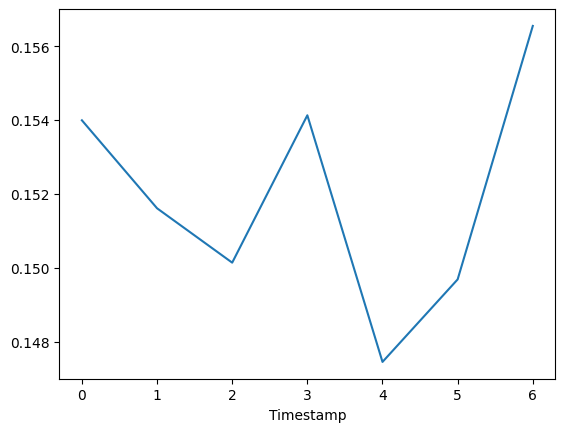

In [ ]:
df_clean.groupby(df_clean.index.dayofweek)["NO3"].mean().plot()

<Axes: xlabel='Timestamp'>

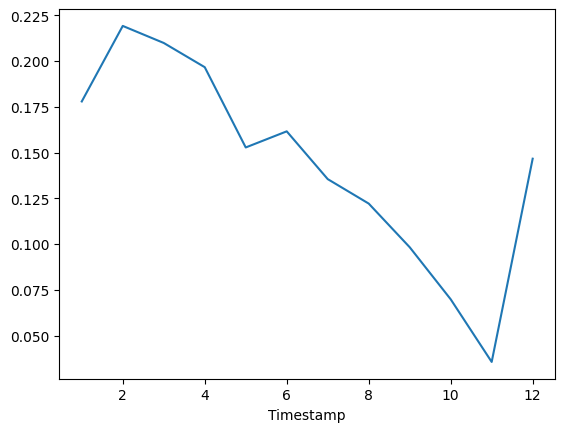

In [ ]:
df_clean.groupby(df_clean.index.month)["NO3"].mean().plot()

## Check Distribution

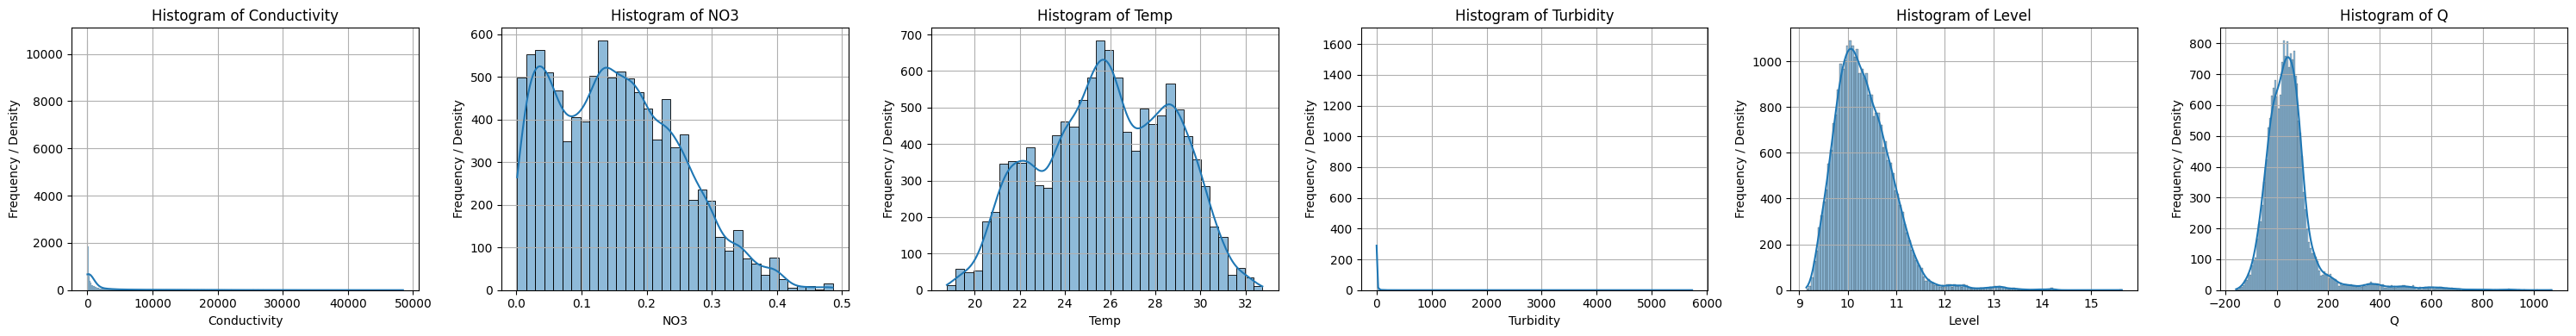

In [ ]:
columns_to_plot = ['Conductivity', 'NO3', 'Temp', 'Turbidity', 'Level', 'Q']

# Histograms for the selected columns
fig, axes = plt.subplots(nrows=1, ncols=len(columns_to_plot), figsize=(30, 4))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    if col in df_inspect.columns:
        sns.histplot(df_inspect[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency / Density')
        axes[i].grid(True)
    else:
        print(f"Column '{col}' not found in df_inspect.")

plt.tight_layout()
plt.show()

# Split data

Choose Mulgrave_river_deeral_joined.csv to train and test the model since the size of dataset is bigger

In [ ]:
X = df_inspect.select_dtypes(include=["number"])

n = len(X)

# 70/15/15 split

train_end = int(0.697 * n)
val_end   = int(0.72 * n)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val:   {X_val.shape}")
print(f"Shape of X_test:  {X_test.shape}")

print("\nX_train:")
display(X_train.head())

print("\nX_val:")
display(X_val.head())

print("\nX_test:")
display(X_test.head())

Shape of X_train: (20248, 8)
Shape of X_val:   (668, 8)
Shape of X_test:  (8135, 8)

X_train:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2016-12-08 13:00:00,-42.611000,NaN,NaN,NaN,NaN,NaN,3,12
2016-12-08 14:00:00,-48.305000,0.0,NaN,NaN,0.0,10.303333,3,12
2016-12-08 15:00:00,-49.874333,0.0,NaN,NaN,0.0,10.602000,3,12
2016-12-08 16:00:00,-35.325000,0.0,NaN,NaN,0.0,10.788000,3,12
2016-12-08 17:00:00,24.020167,0.0,NaN,NaN,0.0,10.820000,3,12



X_val:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2019-04-01 05:00:00,36.812833,54.35,0.232,25.37,13.60,10.682857,0,4
2019-04-01 06:00:00,19.336333,53.87,0.231,25.35,12.18,10.995714,0,4
2019-04-01 07:00:00,31.145167,53.50,0.231,25.34,11.29,11.143333,0,4
2019-04-01 08:00:00,82.043000,52.24,0.237,25.36,11.24,11.118000,0,4
2019-04-01 09:00:00,112.797333,52.35,0.244,25.47,11.16,10.893333,0,4



X_test:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2019-04-29 01:00:00,NaN,NaN,NaN,NaN,NaN,10.005000,0,4
2019-04-29 02:00:00,31.562000,55.09,0.196,24.19,7.06,10.223333,0,4
2019-04-29 03:00:00,28.717667,53.98,0.197,24.09,6.75,10.475000,0,4
2019-04-29 04:00:00,9.826000,NaN,NaN,NaN,NaN,10.755714,0,4
2019-04-29 05:00:00,-1.993500,53.82,0.197,24.05,5.13,11.015000,0,4


# Fill in missing values

different approach for short and long gap (todo)

long gaps should be kept, and windows that have NaNs should be dropped -> realistic

In [ ]:
def gap_length_summary(series):
    is_nan = series.isna()
    groups = (is_nan != is_nan.shift()).cumsum()
    return series[is_nan].groupby(groups).size()

short_gap_limit = 3

for name, df in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    print(f"\n--- Missing Value Patterns ({name}) ---")
    for col in df.columns:
        gaps = gap_length_summary(df[col])
        print(f"\n=== {col} ===")
        print("Total gaps:", len(gaps))

        if len(gaps) == 0:
            print("No missing values")
        else:
            short = (gaps <= short_gap_limit).sum()
            long  = (gaps > short_gap_limit).sum()
            print(f"Short gaps (≤ {short_gap_limit}): {short} ({100 * short / len(gaps):.2f}%)")
            print(f"Long gaps  (> {short_gap_limit}): {long} ({100 * long / len(gaps):.2f}%)")



--- Missing Value Patterns (X_train) ---

=== Q ===
Total gaps: 1326
Short gaps (≤ 3): 364 (27.45%)
Long gaps  (> 3): 962 (72.55%)

=== Conductivity ===
Total gaps: 2666
Short gaps (≤ 3): 2192 (82.22%)
Long gaps  (> 3): 474 (17.78%)

=== NO3 ===
Total gaps: 234
Short gaps (≤ 3): 89 (38.03%)
Long gaps  (> 3): 145 (61.97%)

=== Temp ===
Total gaps: 807
Short gaps (≤ 3): 636 (78.81%)
Long gaps  (> 3): 171 (21.19%)

=== Turbidity ===
Total gaps: 2666
Short gaps (≤ 3): 2192 (82.22%)
Long gaps  (> 3): 474 (17.78%)

=== Level ===
Total gaps: 37
Short gaps (≤ 3): 34 (91.89%)
Long gaps  (> 3): 3 (8.11%)

=== Dayofweek ===
Total gaps: 0
No missing values

=== Month ===
Total gaps: 0
No missing values

--- Missing Value Patterns (X_val) ---

=== Q ===
Total gaps: 27
Short gaps (≤ 3): 19 (70.37%)
Long gaps  (> 3): 8 (29.63%)

=== Conductivity ===
Total gaps: 204
Short gaps (≤ 3): 204 (100.00%)
Long gaps  (> 3): 0 (0.00%)

=== NO3 ===
Total gaps: 204
Short gaps (≤ 3): 204 (100.00%)
Long gaps  (> 3

In [ ]:
# for short gap, use forward-fill
X_train_ffill = X_train.ffill(limit=short_gap_limit)
X_val_ffill   = X_val.ffill(limit=short_gap_limit)
X_test_ffill  = X_test.ffill(limit=short_gap_limit)

# X_train_ffill = X_train.interpolate(method="linear", limit=short_gap_limit)
# X_val_ffill   = X_val.interpolate(method="linear", limit=short_gap_limit)
# X_test_ffill  = X_test.interpolate(method="linear", limit=short_gap_limit)

print("\nMissing values after Linear Interpolation in X_train_linear:")
display(X_train_ffill.isnull().sum())
display(X_train_ffill.head())

print("\nMissing values after Linear Interpolation in X_val_linear:")
display(X_val_ffill.isnull().sum())
display(X_val_ffill.head())

print("\nMissing values after Linear Interpolation in X_test_linear:")
display(X_test_ffill.isnull().sum())
display(X_test_ffill.head())


Missing values after Linear Interpolation in X_train_linear:


,0
Q,2786
Conductivity,1180
NO3,15738
Temp,13460
Turbidity,1180
Level,206
Dayofweek,0
Month,0


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2016-12-08 13:00:00,-42.611000,NaN,NaN,NaN,NaN,NaN,3,12
2016-12-08 14:00:00,-48.305000,0.0,NaN,NaN,0.0,10.303333,3,12
2016-12-08 15:00:00,-49.874333,0.0,NaN,NaN,0.0,10.602000,3,12
2016-12-08 16:00:00,-35.325000,0.0,NaN,NaN,0.0,10.788000,3,12
2016-12-08 17:00:00,24.020167,0.0,NaN,NaN,0.0,10.820000,3,12



Missing values after Linear Interpolation in X_val_linear:


,0
Q,9
Conductivity,0
NO3,0
Temp,0
Turbidity,0
Level,0
Dayofweek,0
Month,0


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2019-04-01 05:00:00,36.812833,54.35,0.232,25.37,13.60,10.682857,0,4
2019-04-01 06:00:00,19.336333,53.87,0.231,25.35,12.18,10.995714,0,4
2019-04-01 07:00:00,31.145167,53.50,0.231,25.34,11.29,11.143333,0,4
2019-04-01 08:00:00,82.043000,52.24,0.237,25.36,11.24,11.118000,0,4
2019-04-01 09:00:00,112.797333,52.35,0.244,25.47,11.16,10.893333,0,4



Missing values after Linear Interpolation in X_test_linear:


,0
Q,1295
Conductivity,386
NO3,629
Temp,386
Turbidity,386
Level,9
Dayofweek,0
Month,0


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
Timestamp,,,,,,,,
2019-04-29 01:00:00,NaN,NaN,NaN,NaN,NaN,10.005000,0,4
2019-04-29 02:00:00,31.562000,55.09,0.196,24.19,7.06,10.223333,0,4
2019-04-29 03:00:00,28.717667,53.98,0.197,24.09,6.75,10.475000,0,4
2019-04-29 04:00:00,9.826000,53.98,0.197,24.09,6.75,10.755714,0,4
2019-04-29 05:00:00,-1.993500,53.82,0.197,24.05,5.13,11.015000,0,4


# STL (Seasonal-Trend decomposition)

- decomposes a time series into trend, seasonal, and residual components

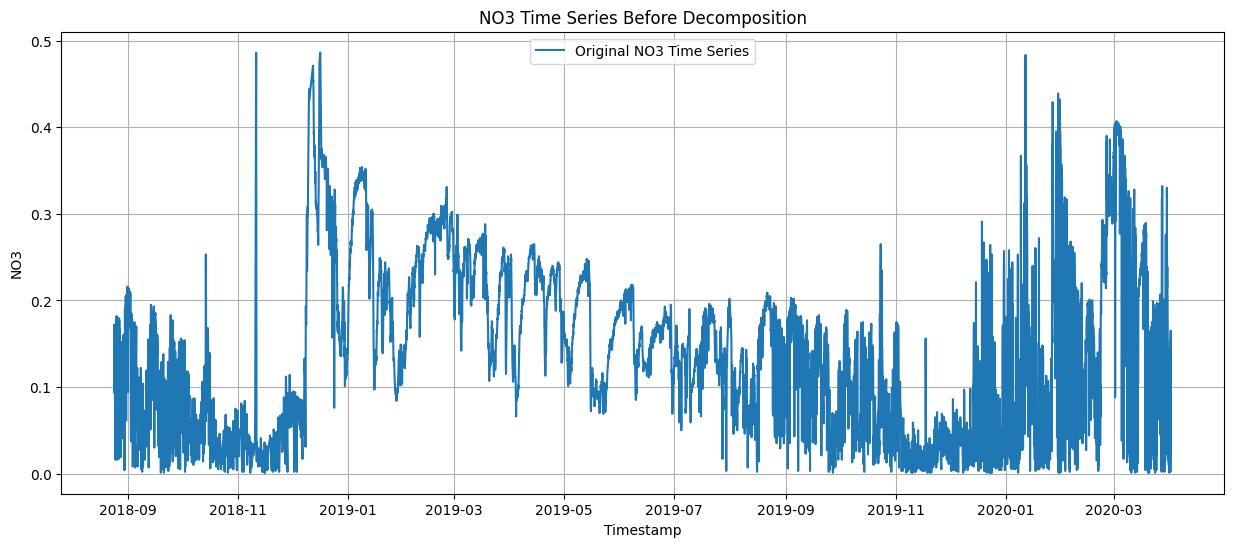

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df_clean["NO3"], label="Original NO3 Time Series")
plt.title("NO3 Time Series Before Decomposition")
plt.xlabel("Timestamp")
plt.ylabel("NO3")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
period = 24
target_col = "NO3"

def apply_stl(df):
    series = df[target_col].dropna()

    stl = STL(series, period=period, robust=True)
    res = stl.fit()

    out = pd.DataFrame({
        "trend": res.trend,
        "seasonal": res.seasonal,
        "residual": res.resid
    }, index=series.index)

    return out

X_train_stl = apply_stl(X_train_ffill)
print("Train STL:")
display(X_train_stl.head())

X_val_stl = apply_stl(X_val_ffill)
print("\nVal STL:")
display(X_val_stl.head())

X_test_stl = apply_stl(X_test_ffill)
print("\nTest STL:")
display(X_test_stl.head())

Train STL:


,trend,seasonal,residual
Timestamp,,,
2018-08-24 08:00:00,0.093172,0.075031,-0.074203
2018-08-24 09:00:00,0.093966,0.007400,-0.000366
2018-08-24 10:00:00,0.094755,0.052862,-0.010617
2018-08-24 11:00:00,0.095540,0.074917,0.001542
2018-08-24 12:00:00,0.096321,0.079958,-0.004279



Val STL:


,trend,seasonal,residual
Timestamp,,,
2019-04-01 05:00:00,0.261783,-0.031711,0.001927
2019-04-01 06:00:00,0.257389,-0.029889,0.003500
2019-04-01 07:00:00,0.253000,-0.023531,0.001531
2019-04-01 08:00:00,0.248618,-0.012638,0.001020
2019-04-01 09:00:00,0.244242,-0.000900,0.000658



Test STL:


,trend,seasonal,residual
Timestamp,,,
2019-04-29 02:00:00,0.166544,0.025207,0.004249
2019-04-29 03:00:00,0.165251,0.028160,0.003589
2019-04-29 04:00:00,0.163967,0.028989,0.004044
2019-04-29 05:00:00,0.162692,0.032167,0.002142
2019-04-29 06:00:00,0.161426,0.033051,0.004523


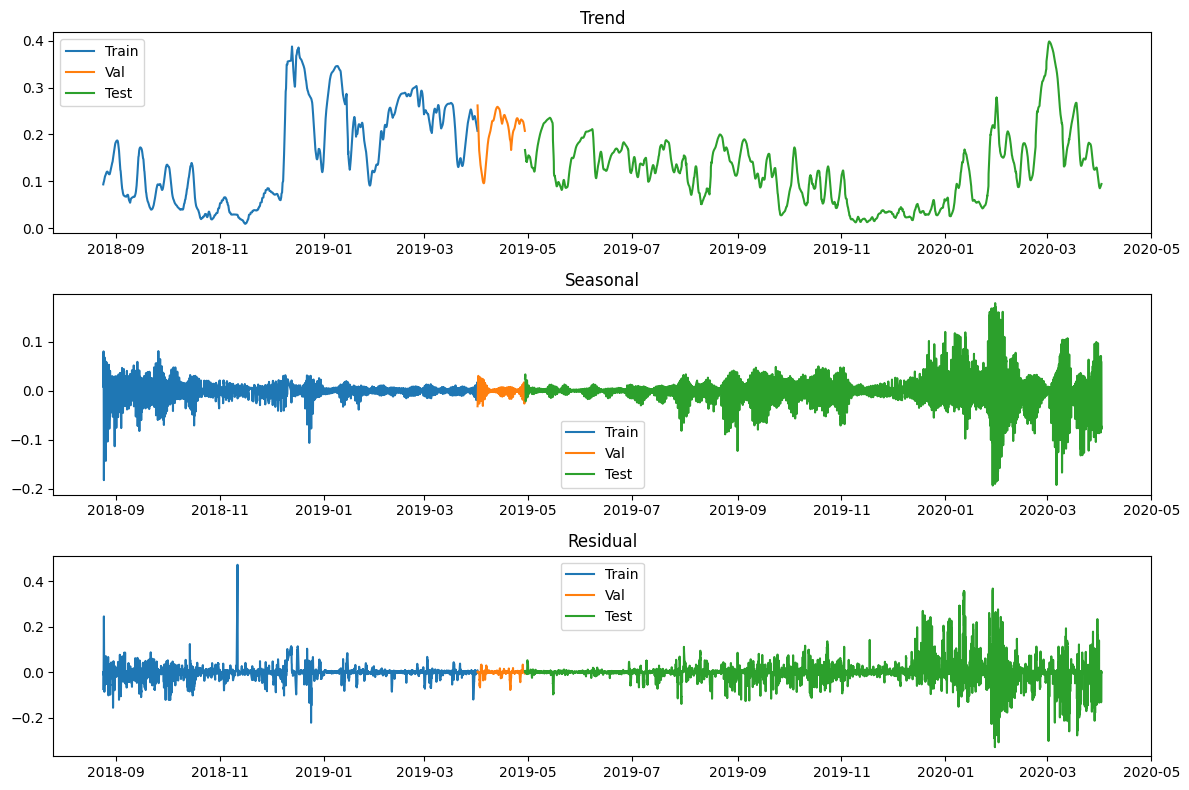

In [ ]:
def plot_all_stl(train, val, test):

    fig, axes = plt.subplots(3,1, figsize=(12,8), sharex=False)

    axes[0].plot(train.index, train["trend"], label="Train")
    axes[0].plot(val.index, val["trend"], label="Val")
    axes[0].plot(test.index, test["trend"], label="Test")
    axes[0].set_title("Trend")
    axes[0].legend()

    axes[1].plot(train.index, train["seasonal"], label="Train")
    axes[1].plot(val.index, val["seasonal"], label="Val")
    axes[1].plot(test.index, test["seasonal"], label="Test")
    axes[1].set_title("Seasonal")
    axes[1].legend()

    axes[2].plot(train.index, train["residual"], label="Train")
    axes[2].plot(val.index, val["residual"], label="Val")
    axes[2].plot(test.index, test["residual"], label="Test")
    axes[2].set_title("Residual")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_all_stl(X_train_stl, X_val_stl, X_test_stl)

In [ ]:
# create trend & seasonal branches
trend_train = X_train_stl["trend"]
trend_val   = X_val_stl["trend"]
trend_test  = X_test_stl["trend"]

season_train = X_train_stl["seasonal"]
season_val   = X_val_stl["seasonal"]
season_test  = X_test_stl["seasonal"]

residual_train = X_train_stl["residual"]
residual_val   = X_val_stl["residual"]
residual_test  = X_test_stl["residual"]

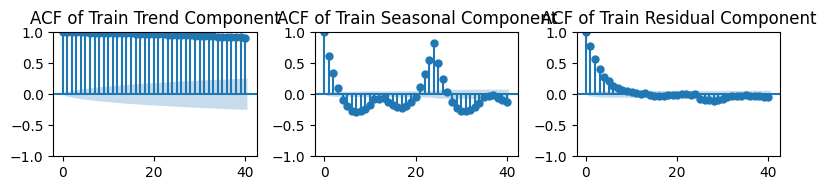

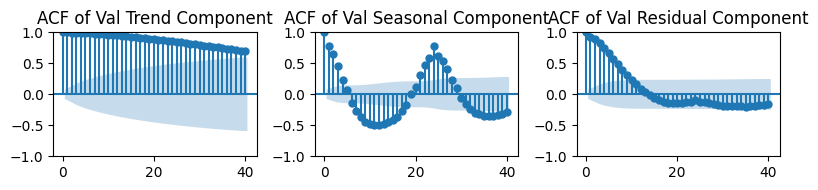

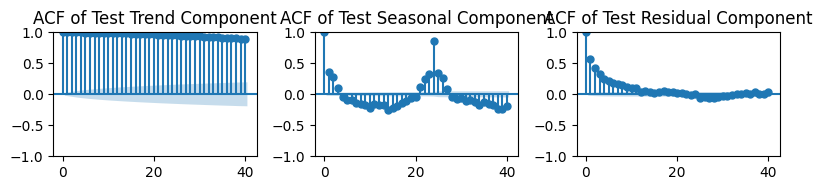

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(8, 2))

plot_acf(trend_train.dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF of Train Trend Component")

plot_acf(season_train.dropna(), lags=40, ax=axes[1])
axes[1].set_title("ACF of Train Seasonal Component")

plot_acf(residual_train.dropna(), lags=40, ax=axes[2])
axes[2].set_title("ACF of Train Residual Component")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(8, 2))

plot_acf(trend_val.dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF of Val Trend Component")

plot_acf(season_val.dropna(), lags=40, ax=axes[1])
axes[1].set_title("ACF of Val Seasonal Component")

plot_acf(residual_val.dropna(), lags=40, ax=axes[2])
axes[2].set_title("ACF of Val Residual Component")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(8, 2))

plot_acf(trend_test.dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF of Test Trend Component")

plot_acf(season_test.dropna(), lags=40, ax=axes[1])
axes[1].set_title("ACF of Test Seasonal Component")

plot_acf(residual_test.dropna(), lags=40, ax=axes[2])
axes[2].set_title("ACF of Test Residual Component")

plt.tight_layout()
plt.show()

# Create Event Indicators

- for residuals as it absorb events, nonlinear effects, shocks

Some variables such as cnductivity and turbidity show event-drive characteristic:
- extreme right skew
- almost all values near zero
- very long tail

So instead of forcing the model to infer this from raw magnitudes, we can explicityly flag them

In [ ]:
X_train_event  = X_train_ffill.copy()
X_val_event    = X_val_ffill.copy()
X_test_event   = X_test_ffill.copy()

conductivity_threshold = X_train_event["Conductivity"].quantile(0.95)
turbidity_threshold = X_train_event["Turbidity"].quantile(0.95)
q_threshold = X_train_event["Q"].quantile(0.95)

# calculate number and percentage of samples <= and > the threshold
for name, df in [("X_train", X_train_event), ("X_val", X_val_event), ("X_test", X_test_event)]:
  total = len(df)
  print(f"\n--- {name} ---")
  for name, threshold in [("Conductivity", conductivity_threshold), ("Turbidity", turbidity_threshold), ("Q", q_threshold)]:
    print(f"\n=== {name} ===")
    lower_equal = (df[name] <= threshold).sum()
    upper = (df[name] > threshold).sum()
    print(f"<= {threshold:.6f}: {lower_equal} ({lower_equal / total * 100:.2f}%)")
    print(f"> {threshold:.6f}: {upper} ({upper / total * 100:.2f}%)")

X_train_event["Conductivity_event"] = (X_train_event["Conductivity"] > conductivity_threshold).astype(int)
X_val_event["Conductivity_event"]   = (X_val_event["Conductivity"]   > conductivity_threshold).astype(int)
X_test_event["Conductivity_event"]  = (X_test_event["Conductivity"]  > conductivity_threshold).astype(int)

X_train_event["Turbidity_event"] = (X_train_event["Turbidity"] > turbidity_threshold).astype(int)
X_val_event["Turbidity_event"]   = (X_val_event["Turbidity"]   > turbidity_threshold).astype(int)
X_test_event["Turbidity_event"]  = (X_test_event["Turbidity"]  > turbidity_threshold).astype(int)

X_train_event["Q_event"] = (X_train_event["Q"] > q_threshold).astype(int)
X_val_event["Q_event"]   = (X_val_event["Q"]   > q_threshold).astype(int)
X_test_event["Q_event"]  = (X_test_event["Q"]  > q_threshold).astype(int)

print("Train set:")
display(X_train_event.head())
print("\nVal set:")
display(X_val_event.head())
print("\nTest set:")
display(X_test_event.head())


--- X_train ---

=== Conductivity ===
<= 13550.600000: 18116 (89.47%)
> 13550.600000: 952 (4.70%)

=== Turbidity ===
<= 64.449500: 18114 (89.46%)
> 64.449500: 954 (4.71%)

=== Q ===
<= 229.671025: 16588 (81.92%)
> 229.671025: 874 (4.32%)

--- X_val ---

=== Conductivity ===
<= 13550.600000: 668 (100.00%)
> 13550.600000: 0 (0.00%)

=== Turbidity ===
<= 64.449500: 668 (100.00%)
> 64.449500: 0 (0.00%)

=== Q ===
<= 229.671025: 579 (86.68%)
> 229.671025: 80 (11.98%)

--- X_test ---

=== Conductivity ===
<= 13550.600000: 7237 (88.96%)
> 13550.600000: 512 (6.29%)

=== Turbidity ===
<= 64.449500: 7696 (94.60%)
> 64.449500: 53 (0.65%)

=== Q ===
<= 229.671025: 6839 (84.07%)
> 229.671025: 1 (0.01%)
Train set:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,
2016-12-08 13:00:00,-42.611000,NaN,NaN,NaN,NaN,NaN,3,12,0,0,0
2016-12-08 14:00:00,-48.305000,0.0,NaN,NaN,0.0,10.303333,3,12,0,0,0
2016-12-08 15:00:00,-49.874333,0.0,NaN,NaN,0.0,10.602000,3,12,0,0,0
2016-12-08 16:00:00,-35.325000,0.0,NaN,NaN,0.0,10.788000,3,12,0,0,0
2016-12-08 17:00:00,24.020167,0.0,NaN,NaN,0.0,10.820000,3,12,0,0,0



Val set:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,
2019-04-01 05:00:00,36.812833,54.35,0.232,25.37,13.60,10.682857,0,4,0,0,0
2019-04-01 06:00:00,19.336333,53.87,0.231,25.35,12.18,10.995714,0,4,0,0,0
2019-04-01 07:00:00,31.145167,53.50,0.231,25.34,11.29,11.143333,0,4,0,0,0
2019-04-01 08:00:00,82.043000,52.24,0.237,25.36,11.24,11.118000,0,4,0,0,0
2019-04-01 09:00:00,112.797333,52.35,0.244,25.47,11.16,10.893333,0,4,0,0,0



Test set:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,
2019-04-29 01:00:00,NaN,NaN,NaN,NaN,NaN,10.005000,0,4,0,0,0
2019-04-29 02:00:00,31.562000,55.09,0.196,24.19,7.06,10.223333,0,4,0,0,0
2019-04-29 03:00:00,28.717667,53.98,0.197,24.09,6.75,10.475000,0,4,0,0,0
2019-04-29 04:00:00,9.826000,53.98,0.197,24.09,6.75,10.755714,0,4,0,0,0
2019-04-29 05:00:00,-1.993500,53.82,0.197,24.05,5.13,11.015000,0,4,0,0,0


# Log Transformation

In [ ]:
log_cols = ["Turbidity", "Conductivity", "Q"]

X_train_log = X_train_event.copy()
X_val_log   = X_val_event.copy()
X_test_log  = X_test_event.copy()

for event_df, log_df in [(X_train_event, X_train_log), (X_val_event, X_val_log), (X_test_event, X_test_log)]:
    for col in log_cols:
        log_df[col] = np.log1p(event_df[col])

print("Log-transformed columns:")
print("Train set")
display(X_train_log.head())
print("\nVal set")
display(X_val_log.head())
print("\nTest set")
display(X_test_log.head())

Log-transformed columns:
Train set


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,
2016-12-08 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,3,12,0,0,0
2016-12-08 14:00:00,NaN,0.0,NaN,NaN,0.0,10.303333,3,12,0,0,0
2016-12-08 15:00:00,NaN,0.0,NaN,NaN,0.0,10.602000,3,12,0,0,0
2016-12-08 16:00:00,NaN,0.0,NaN,NaN,0.0,10.788000,3,12,0,0,0
2016-12-08 17:00:00,3.219682,0.0,NaN,NaN,0.0,10.820000,3,12,0,0,0



Val set


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,
2019-04-01 05:00:00,3.632649,4.013677,0.232,25.37,2.681022,10.682857,0,4,0,0,0
2019-04-01 06:00:00,3.012409,4.004967,0.231,25.35,2.578701,10.995714,0,4,0,0,0
2019-04-01 07:00:00,3.470262,3.998201,0.231,25.34,2.508786,11.143333,0,4,0,0,0
2019-04-01 08:00:00,4.419359,3.974810,0.237,25.36,2.504709,11.118000,0,4,0,0,0
2019-04-01 09:00:00,4.734419,3.976874,0.244,25.47,2.498152,10.893333,0,4,0,0,0



Test set


,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,
2019-04-29 01:00:00,NaN,NaN,NaN,NaN,NaN,10.005000,0,4,0,0,0
2019-04-29 02:00:00,3.483146,4.026958,0.196,24.19,2.086914,10.223333,0,4,0,0,0
2019-04-29 03:00:00,3.391742,4.006969,0.197,24.09,2.047693,10.475000,0,4,0,0,0
2019-04-29 04:00:00,2.381951,4.006969,0.197,24.09,2.047693,10.755714,0,4,0,0,0
2019-04-29 05:00:00,NaN,4.004055,0.197,24.05,1.813195,11.015000,0,4,0,0,0


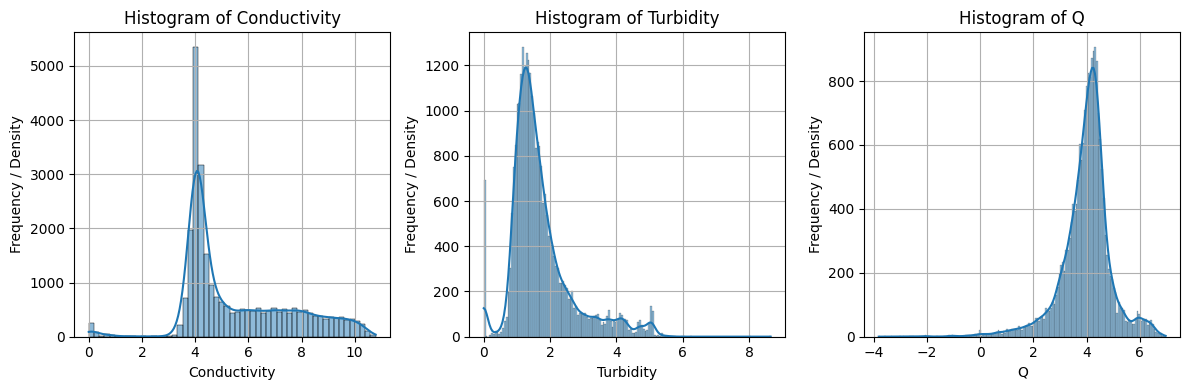

In [ ]:
columns_to_plot = ['Conductivity', 'Turbidity', "Q"]

# aggr train, val, test
df_aggr = pd.concat([X_train_log, X_val_log, X_test_log])

# Histograms for the selected columns
fig, axes = plt.subplots(nrows=1, ncols=len(columns_to_plot), figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    if col in df_aggr.columns:
        sns.histplot(df_aggr[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency / Density')
        axes[i].grid(True)
    else:
        print(f"Column '{col}' not found in df.")


plt.tight_layout()
plt.show()

# Time Features Encoding

In [ ]:
def add_cyclic_time_features(df):
    """
    Add cyclic hour-of-day and month-of-year features.
    Assumes df has a DatetimeIndex.
    """
    df = df.copy()

    # hour of day
    hour = df.index.hour
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    # week of day
    # day_of_week = df.index.dayofweek
    # df["dayofweek_sin"] = np.sin(2 * np.pi * day_of_week / 7)
    # df["dayofweek_cos"] = np.cos(2 * np.pi * day_of_week / 7)

    # month of year
    month = df.index.month
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)

    # drop redundant / raw calendar columns if they exist
    cols_to_drop = [c for c in ["Dayofweek", "Month", "hour"] if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    return df

X_train_time = add_cyclic_time_features(X_train_log)
X_val_time   = add_cyclic_time_features(X_val_log)
X_test_time  = add_cyclic_time_features(X_test_log)

print("X_train_time:")
display(X_train_time.head())
print("\nX_val_time:")
display(X_val_time.head())
print("\nX_test_time:")
display(X_test_time.head())

X_train_time:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Conductivity_event,Turbidity_event,Q_event,hour_sin,hour_cos,month_sin,month_cos
Timestamp,,,,,,,,,,,,,
2016-12-08 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,-0.258819,-0.965926,-2.449294e-16,1.0
2016-12-08 14:00:00,NaN,0.0,NaN,NaN,0.0,10.303333,0,0,0,-0.500000,-0.866025,-2.449294e-16,1.0
2016-12-08 15:00:00,NaN,0.0,NaN,NaN,0.0,10.602000,0,0,0,-0.707107,-0.707107,-2.449294e-16,1.0
2016-12-08 16:00:00,NaN,0.0,NaN,NaN,0.0,10.788000,0,0,0,-0.866025,-0.500000,-2.449294e-16,1.0
2016-12-08 17:00:00,3.219682,0.0,NaN,NaN,0.0,10.820000,0,0,0,-0.965926,-0.258819,-2.449294e-16,1.0



X_val_time:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Conductivity_event,Turbidity_event,Q_event,hour_sin,hour_cos,month_sin,month_cos
Timestamp,,,,,,,,,,,,,
2019-04-01 05:00:00,3.632649,4.013677,0.232,25.37,2.681022,10.682857,0,0,0,0.965926,2.588190e-01,0.866025,-0.5
2019-04-01 06:00:00,3.012409,4.004967,0.231,25.35,2.578701,10.995714,0,0,0,1.000000,6.123234e-17,0.866025,-0.5
2019-04-01 07:00:00,3.470262,3.998201,0.231,25.34,2.508786,11.143333,0,0,0,0.965926,-2.588190e-01,0.866025,-0.5
2019-04-01 08:00:00,4.419359,3.974810,0.237,25.36,2.504709,11.118000,0,0,0,0.866025,-5.000000e-01,0.866025,-0.5
2019-04-01 09:00:00,4.734419,3.976874,0.244,25.47,2.498152,10.893333,0,0,0,0.707107,-7.071068e-01,0.866025,-0.5



X_test_time:


,Q,Conductivity,NO3,Temp,Turbidity,Level,Conductivity_event,Turbidity_event,Q_event,hour_sin,hour_cos,month_sin,month_cos
Timestamp,,,,,,,,,,,,,
2019-04-29 01:00:00,NaN,NaN,NaN,NaN,NaN,10.005000,0,0,0,0.258819,0.965926,0.866025,-0.5
2019-04-29 02:00:00,3.483146,4.026958,0.196,24.19,2.086914,10.223333,0,0,0,0.500000,0.866025,0.866025,-0.5
2019-04-29 03:00:00,3.391742,4.006969,0.197,24.09,2.047693,10.475000,0,0,0,0.707107,0.707107,0.866025,-0.5
2019-04-29 04:00:00,2.381951,4.006969,0.197,24.09,2.047693,10.755714,0,0,0,0.866025,0.500000,0.866025,-0.5
2019-04-29 05:00:00,NaN,4.004055,0.197,24.05,1.813195,11.015000,0,0,0,0.965926,0.258819,0.866025,-0.5


# Normalization

Considering we will use LSTM, Z-score (StandardScaler) is better

In [ ]:
# columns to scale (exclude target)
feature_cols = ['Q', 'Level', 'Temp', 'Turbidity', 'Conductivity']

scaler = StandardScaler()

# fit on TRAIN only
X_train_scaled = X_train_time.copy()
X_val_scaled   = X_val_time.copy()
X_test_scaled  = X_test_time.copy()

X_train_scaled[feature_cols] = scaler.fit_transform(X_train_time[feature_cols])
X_val_scaled[feature_cols]   = scaler.transform(X_val_time[feature_cols])
X_test_scaled[feature_cols]  = scaler.transform(X_test_time[feature_cols])

# enforce column order explicitly
ordered_cols = feature_cols + [target_col] + ["hour_sin", "hour_cos", "month_sin", "month_cos", "Conductivity_event", "Turbidity_event", "Q_event"]
X_train_scaled = X_train_scaled[ordered_cols]
X_val_scaled   = X_val_scaled[ordered_cols]
X_test_scaled  = X_test_scaled[ordered_cols]

print("Scaled X_train:")
display(X_train_scaled.head())
print("\nScaled X_val:")
display(X_val_scaled.head())
print("\nScaled X_test:")
display(X_test_scaled.head())

Scaled X_train:


,Q,Level,Temp,Turbidity,Conductivity,NO3,hour_sin,hour_cos,month_sin,month_cos,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,,,
2016-12-08 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-0.258819,-0.965926,-2.449294e-16,1.0,0,0,0
2016-12-08 14:00:00,NaN,-0.107837,NaN,-1.719574,-2.677495,NaN,-0.500000,-0.866025,-2.449294e-16,1.0,0,0,0
2016-12-08 15:00:00,NaN,0.364378,NaN,-1.719574,-2.677495,NaN,-0.707107,-0.707107,-2.449294e-16,1.0,0,0,0
2016-12-08 16:00:00,NaN,0.658459,NaN,-1.719574,-2.677495,NaN,-0.866025,-0.500000,-2.449294e-16,1.0,0,0,0
2016-12-08 17:00:00,-0.799755,0.709053,NaN,-1.719574,-2.677495,NaN,-0.965926,-0.258819,-2.449294e-16,1.0,0,0,0



Scaled X_val:


,Q,Level,Temp,Turbidity,Conductivity,NO3,hour_sin,hour_cos,month_sin,month_cos,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,,,
2019-04-01 05:00:00,-0.387919,0.492220,-0.074682,0.819551,-0.701548,0.232,0.965926,2.588190e-01,0.866025,-0.5,0,0,0
2019-04-01 06:00:00,-1.006460,0.986871,-0.082046,0.722646,-0.705835,0.231,1.000000,6.123234e-17,0.866025,-0.5,0,0,0
2019-04-01 07:00:00,-0.549861,1.220268,-0.085727,0.656432,-0.709166,0.231,0.965926,-2.588190e-01,0.866025,-0.5,0,0,0
2019-04-01 08:00:00,0.396636,1.180214,-0.078364,0.652571,-0.720682,0.237,0.866025,-5.000000e-01,0.866025,-0.5,0,0,0
2019-04-01 09:00:00,0.710834,0.824999,-0.037866,0.646360,-0.719666,0.244,0.707107,-7.071068e-01,0.866025,-0.5,0,0,0



Scaled X_test:


,Q,Level,Temp,Turbidity,Conductivity,NO3,hour_sin,hour_cos,month_sin,month_cos,Conductivity_event,Turbidity_event,Q_event
Timestamp,,,,,,,,,,,,,
2019-04-29 01:00:00,NaN,-0.579525,NaN,NaN,NaN,NaN,0.258819,0.965926,0.866025,-0.5,0,0,0
2019-04-29 02:00:00,-0.537013,-0.234323,-0.509115,0.256887,-0.695009,0.196,0.500000,0.866025,0.866025,-0.5,0,0,0
2019-04-29 03:00:00,-0.628167,0.163582,-0.545932,0.219742,-0.704850,0.197,0.707107,0.707107,0.866025,-0.5,0,0,0
2019-04-29 04:00:00,-1.635193,0.607412,-0.545932,0.219742,-0.704850,0.197,0.866025,0.500000,0.866025,-0.5,0,0,0
2019-04-29 05:00:00,NaN,1.017363,-0.560658,-0.002345,-0.706284,0.197,0.965926,0.258819,0.866025,-0.5,0,0,0


# Decide what features assigned to which component

In [ ]:
trend_season_features = ["Q", "Level", "Temp", "Turbidity", "Conductivity"]
residual_features = ["Conductivity_event", "Turbidity_event", "Q_event", "hour_sin", "hour_cos", "month_sin", "month_cos"]

# For trend component
# Combine X_train_scaled features with the trend_train series
# rename the col 'trend' to 'NO3'
X_trend_train = pd.concat([X_train_scaled[trend_season_features], trend_train.rename(target_col)], axis=1)
X_trend_val   = pd.concat([X_val_scaled[trend_season_features], trend_val.rename(target_col)], axis=1)
X_trend_test  = pd.concat([X_test_scaled[trend_season_features], trend_test.rename(target_col)], axis=1)

print("Trend Train set:")
display(X_trend_train.head())
print("\nTrend Val set:")
display(X_trend_val.head())
print("\nTrend Test set:")
display(X_trend_test.head())

# For seasonal component
# Combine X_train_scaled features with the season_train series
X_season_train = pd.concat([X_train_scaled[trend_season_features], season_train.rename(target_col)], axis=1)
X_season_val   = pd.concat([X_val_scaled[trend_season_features], season_val.rename(target_col)], axis=1)
X_season_test  = pd.concat([X_test_scaled[trend_season_features], season_test.rename(target_col)], axis=1)

print("\nSeason Train set:")
display(X_season_train.head())
print("\nSeason Val set:")
display(X_season_val.head())
print("\nSeason Test set:")
display(X_season_test.head())

# For residual component
# Combine X_train_scaled features with the residual_train series
X_residual_train = pd.concat([X_train_scaled[residual_features], residual_train.rename(target_col)], axis=1)
X_residual_val   = pd.concat([X_val_scaled[residual_features], residual_val.rename(target_col)], axis=1)
X_residual_test  = pd.concat([X_test_scaled[residual_features], residual_test.rename(target_col)], axis=1)

print("\nResidual Train set:")
display(X_residual_train.head())
print("\nResidual Val set:")
display(X_residual_val.head())
print("\nResidual Test set:")
display(X_residual_test.head())

Trend Train set:


,Q,Level,Temp,Turbidity,Conductivity,NO3
Timestamp,,,,,,
2016-12-08 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-08 14:00:00,NaN,-0.107837,NaN,-1.719574,-2.677495,NaN
2016-12-08 15:00:00,NaN,0.364378,NaN,-1.719574,-2.677495,NaN
2016-12-08 16:00:00,NaN,0.658459,NaN,-1.719574,-2.677495,NaN
2016-12-08 17:00:00,-0.799755,0.709053,NaN,-1.719574,-2.677495,NaN



Trend Val set:


,Q,Level,Temp,Turbidity,Conductivity,NO3
Timestamp,,,,,,
2019-04-01 05:00:00,-0.387919,0.492220,-0.074682,0.819551,-0.701548,0.261783
2019-04-01 06:00:00,-1.006460,0.986871,-0.082046,0.722646,-0.705835,0.257389
2019-04-01 07:00:00,-0.549861,1.220268,-0.085727,0.656432,-0.709166,0.253000
2019-04-01 08:00:00,0.396636,1.180214,-0.078364,0.652571,-0.720682,0.248618
2019-04-01 09:00:00,0.710834,0.824999,-0.037866,0.646360,-0.719666,0.244242



Trend Test set:


...

,Conductivity_event,Turbidity_event,Q_event,hour_sin,hour_cos,month_sin,month_cos,NO3
Timestamp,,,,,,,,
2016-12-08 13:00:00,0,0,0,-0.258819,-0.965926,-2.449294e-16,1.0,NaN
2016-12-08 14:00:00,0,0,0,-0.500000,-0.866025,-2.449294e-16,1.0,NaN
2016-12-08 15:00:00,0,0,0,-0.707107,-0.707107,-2.449294e-16,1.0,NaN
2016-12-08 16:00:00,0,0,0,-0.866025,-0.500000,-2.449294e-16,1.0,NaN
2016-12-08 17:00:00,0,0,0,-0.965926,-0.258819,-2.449294e-16,1.0,NaN



Residual Val set:


,Conductivity_event,Turbidity_event,Q_event,hour_sin,hour_cos,month_sin,month_cos,NO3
Timestamp,,,,,,,,
2019-04-01 05:00:00,0,0,0,0.965926,2.588190e-01,0.866025,-0.5,0.001927
2019-04-01 06:00:00,0,0,0,1.000000,6.123234e-17,0.866025,-0.5,0.003500
2019-04-01 07:00:00,0,0,0,0.965926,-2.588190e-01,0.866025,-0.5,0.001531
2019-04-01 08:00:00,0,0,0,0.866025,-5.000000e-01,0.866025,-0.5,0.001020
2019-04-01 09:00:00,0,0,0,0.707107,-7.071068e-01,0.866025,-0.5,0.000658



Residual Test set:


,Conductivity_event,Turbidity_event,Q_event,hour_sin,hour_cos,month_sin,month_cos,NO3
Timestamp,,,,,,,,
2019-04-29 01:00:00,0,0,0,0.258819,0.965926,0.866025,-0.5,NaN
2019-04-29 02:00:00,0,0,0,0.500000,0.866025,0.866025,-0.5,0.004249
2019-04-29 03:00:00,0,0,0,0.707107,0.707107,0.866025,-0.5,0.003589
2019-04-29 04:00:00,0,0,0,0.866025,0.500000,0.866025,-0.5,0.004044
2019-04-29 05:00:00,0,0,0,0.965926,0.258819,0.866025,-0.5,0.002142


# Data windowing

- trend: capture long-term structure, external events add noise
- seasonal: seasonality is deterministic and stable, extra feature is not

In [ ]:
trend_look_back = 72
season_look_back = 24
residual_look_back = 24

forecast_horizon = 12

def create_sequences(dataframe, look_back, forecast_horizon):
    X, y, t0 = [], [], []
    # Adjust the range for the forecast horizon
    for i in range(look_back, len(dataframe) - forecast_horizon + 1):
        # Features are all columns in the look_back window
        X.append(dataframe.iloc[i-look_back : i].values)
        # Target is the target_column value at the forecast_horizon step
        y.append(dataframe.iloc[i + forecast_horizon - 1][target_col])
        # Save timestamps
        t0.append(dataframe.index[i])
    return np.array(X), np.array(y), np.array(t0) # for x, shape = (batch, lookback, feature), for y, shape = (batch, 1)

def drop_nan_windows(X, y, t0):
    mask = ~np.isnan(X).any(axis=(1, 2)) & ~np.isnan(y)
    return X[mask], y[mask], t0[mask]


X_trend_train_windowed, y_trend_train_windowed, t_trend_train = create_sequences(X_trend_train, trend_look_back, forecast_horizon)
X_trend_val_windowed, y_trend_val_windowed, t_trend_val = create_sequences(X_trend_val, trend_look_back, forecast_horizon)
X_trend_test_windowed, y_trend_test_windowed, t_trend_test = create_sequences(X_trend_test, trend_look_back, forecast_horizon)

X_trend_train_windowed, y_trend_train_windowed, t_trend_train = drop_nan_windows(X_trend_train_windowed, y_trend_train_windowed, t_trend_train)
X_trend_val_windowed,   y_trend_val_windowed, t_trend_val   = drop_nan_windows(X_trend_val_windowed, y_trend_val_windowed, t_trend_val)
X_trend_test_windowed,  y_trend_test_windowed, t_trend_test  = drop_nan_windows(X_trend_test_windowed, y_trend_test_windowed, t_trend_test)

print("Trend Train:", X_trend_train_windowed.shape, "Start:", t_trend_train[0], "End:", t_trend_train[-1])
print("Trend Val:  ", X_trend_val_windowed.shape, "Start:", t_trend_val[0], "End:", t_trend_val[-1])
print("Trend Test: ", X_trend_test_windowed.shape, "Start:", t_trend_test[0], "End:", t_trend_test[-1])


X_season_train_windowed, y_season_train_windowed, t_season_train = create_sequences(X_season_train, season_look_back, forecast_horizon)
X_season_val_windowed, y_season_val_windowed, t_season_val = create_sequences(X_season_val, season_look_back, forecast_horizon)
X_season_test_windowed, y_season_test_windowed, t_season_test = create_sequences(X_season_test, season_look_back, forecast_horizon)

X_season_train_windowed, y_season_train_windowed, t_season_train = drop_nan_windows(X_season_train_windowed, y_season_train_windowed, t_season_train)
X_season_val_windowed,   y_season_val_windowed, t_season_val = drop_nan_windows(X_season_val_windowed, y_season_val_windowed, t_season_val)
X_season_test_windowed,  y_season_test_windowed, t_season_test = drop_nan_windows(X_season_test_windowed, y_season_test_windowed, t_season_test)

print("\nSeason Train:", X_season_train_windowed.shape, "Start:", t_season_train[0], "End:", t_season_train[-1])
print("Season Val:  ", X_season_val_windowed.shape, "Start:", t_season_val[0], "End:", t_season_val[-1])
print("Season Test: ", X_season_test_windowed.shape, "Start:", t_season_test[0], "End:", t_season_test[-1])


X_residual_train_windowed, y_residual_train_windowed, t_residual_train = create_sequences(X_residual_train, residual_look_back, forecast_horizon)
X_residual_val_windowed, y_residual_val_windowed, t_residual_val = create_sequences(X_residual_val, residual_look_back, forecast_horizon)
X_residual_test_windowed, y_residual_test_windowed, t_residual_test = create_sequences(X_residual_test, residual_look_back, forecast_horizon)

X_residual_train_windowed, y_residual_train_windowed, t_residual_train = drop_nan_windows(X_residual_train_windowed, y_residual_train_windowed, t_residual_train)
X_residual_val_windowed,   y_residual_val_windowed, t_residual_val = drop_nan_windows(X_residual_val_windowed, y_residual_val_windowed, t_residual_val)
X_residual_test_windowed,  y_residual_test_windowed, t_residual_test = drop_nan_windows(X_residual_test_windowed, y_residual_test_windowed, t_residual_test)

print("\nResidual Train:", X_residual_train_windowed.shape, "Start:", t_residual_train[0], "End:", t_residual_train[-1])
print("Residual Val:  ", X_residual_val_windowed.shape, "Start:", t_residual_val[0], "End:", t_residual_val[-1])
print("Residual Test: ", X_residual_test_windowed.shape, "Start:", t_residual_test[0], "End:", t_residual_test[-1])

Trend Train: (931, 72, 6) Start: 2018-12-27 11:00:00 End: 2019-03-31 17:00:00
Trend Val:   (239, 72, 6) Start: 2019-04-04 05:00:00 End: 2019-04-14 03:00:00
Trend Test:  (218, 72, 6) Start: 2019-05-04 07:00:00 End: 2020-04-01 06:00:00

Season Train: (1232, 24, 6) Start: 2018-12-17 13:00:00 End: 2019-03-31 17:00:00
Season Val:   (289, 24, 6) Start: 2019-04-02 05:00:00 End: 2019-04-25 21:00:00
Season Test:  (483, 24, 6) Start: 2019-05-01 06:00:00 End: 2020-04-01 06:00:00

Residual Train: (2606, 24, 8) Start: 2018-08-31 19:00:00 End: 2019-03-31 17:00:00
Residual Val:   (633, 24, 8) Start: 2019-04-02 05:00:00 End: 2019-04-28 13:00:00
Residual Test:  (3000, 24, 8) Start: 2019-04-30 02:00:00 End: 2020-04-01 06:00:00


## Flatten data

In [ ]:
X_trend_train_flattened = X_trend_train_windowed.reshape(X_trend_train_windowed.shape[0], -1)
X_trend_val_flattened = X_trend_val_windowed.reshape(X_trend_val_windowed.shape[0], -1)
X_trend_test_flattened = X_trend_test_windowed.reshape(X_trend_test_windowed.shape[0], -1)

print(f"Shape of X_trend_train_flattened: {X_trend_train_flattened.shape}")
print(f"Shape of X_trend_val_flattened: {X_trend_val_flattened.shape}")
print(f"Shape of X_trend_test_flattened: {X_trend_test_flattened.shape}")


X_season_train_flattened = X_season_train_windowed.reshape(X_season_train_windowed.shape[0], -1)
X_season_val_flattened = X_season_val_windowed.reshape(X_season_val_windowed.shape[0], -1)
X_season_test_flattened = X_season_test_windowed.reshape(X_season_test_windowed.shape[0], -1)

print(f"\nShape of X_season_train_flattened: {X_season_train_flattened.shape}")
print(f"Shape of X_season_val_flattened: {X_season_val_flattened.shape}")
print(f"Shape of X_season_test_flattened: {X_season_test_flattened.shape}")


X_residual_train_flattened = X_residual_train_windowed.reshape(X_residual_train_windowed.shape[0], -1)
X_residual_val_flattened = X_residual_val_windowed.reshape(X_residual_val_windowed.shape[0], -1)
X_residual_test_flattened = X_residual_test_windowed.reshape(X_residual_test_windowed.shape[0], -1)

print(f"\nShape of X_residual_train_flattened: {X_residual_train_flattened.shape}")
print(f"Shape of X_residual_val_flattened: {X_residual_val_flattened.shape}")
print(f"Shape of X_residual_test_flattened: {X_residual_test_flattened.shape}")

Shape of X_trend_train_flattened: (931, 432)
Shape of X_trend_val_flattened: (239, 432)
Shape of X_trend_test_flattened: (218, 432)

Shape of X_season_train_flattened: (1232, 144)
Shape of X_season_val_flattened: (289, 144)
Shape of X_season_test_flattened: (483, 144)

Shape of X_residual_train_flattened: (2606, 192)
Shape of X_residual_val_flattened: (633, 192)
Shape of X_residual_test_flattened: (3000, 192)


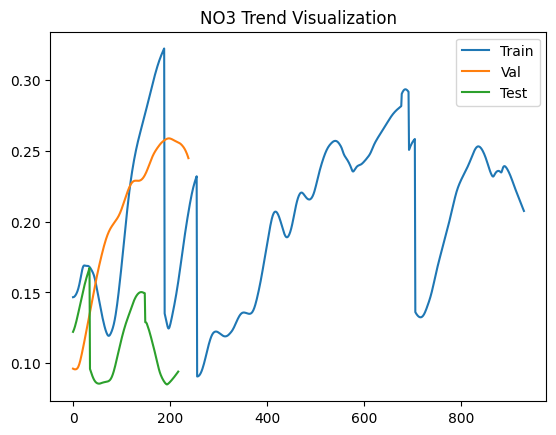

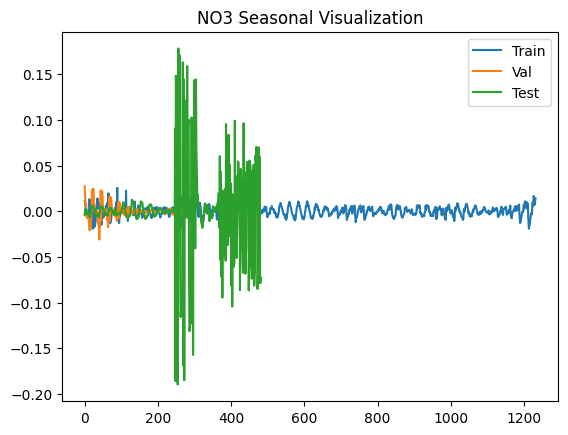

Text(0.5, 1.0, 'NO3 Residual Visualization')

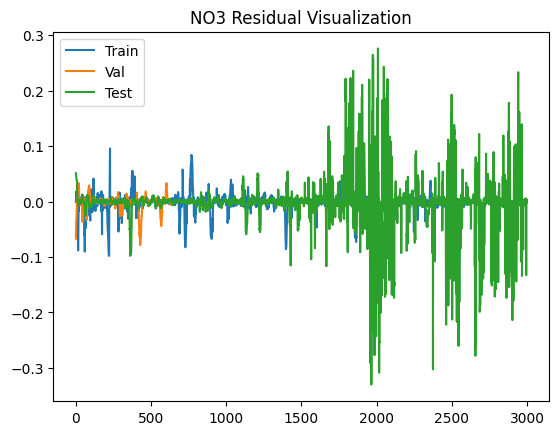

In [ ]:
plt.plot(y_trend_train_windowed)
plt.plot(y_trend_val_windowed)
plt.plot(y_trend_test_windowed)
plt.legend(["Train", "Val", "Test"])
plt.title("NO3 Trend Visualization")
plt.show()

plt.plot(y_season_train_windowed)
plt.plot(y_season_val_windowed)
plt.plot(y_season_test_windowed)
plt.legend(["Train", "Val", "Test"])
plt.title("NO3 Seasonal Visualization")
plt.show()

plt.plot(y_residual_train_windowed)
plt.plot(y_residual_val_windowed)
plt.plot(y_residual_test_windowed)
plt.legend(["Train", "Val", "Test"])
plt.title("NO3 Residual Visualization")

# Define Hyperparameter Spaces

In [ ]:
gru_hyperparameter_space = {
    'units': [32, 64, 128],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [0.005, 0.001, 0.0005]
}

lstm_hyperparameter_space = {
    'units': [32, 64, 128],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [0.005, 0.001, 0.0005]
}

# narnet and mlp should be 3 layer
narnet_hyperparameter_space = {
    'dense_units': [[64, 32, 16], [128, 64, 32], [256, 128, 64]],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [0.005, 0.001, 0.0005]
}

mlp_hyperparameter_space = {
    'hidden_layer_sizes': [[64, 32, 16], [128, 64, 32], [256, 128, 64]],
    'learning_rate': [0.005, 0.001, 0.0005],
    'dropout_rate': [0.1, 0.2, 0.3]
}

rf_hyperparameter_space = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

xgb_hyperparameter_space = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5]
}

svr_hyperparameter_space = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2]
}

print("Hyperparameter spaces defined.")

Hyperparameter spaces defined.


# Define Evaluation Metrics

In [ ]:
def calc_metrics(y_true, y_pred):
    """
    Calculates Mean Squared Error (MSE), Root Mean Squared Error (RMSE),
    R-squared (R2), and Mean Absolute Error (MAE).

    Args:
        y_true (array-like): True values.
        y_pred (array-like): Predicted values.

    Returns:
        tuple: A tuple containing (mse, rmse, r2, mae).
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2, mae

print("Metrics calculation function defined.")

Metrics calculation function defined.


# Train

## Trend

### GRU

In [ ]:
def train_evaluate_gru(X_train, y_train, X_val, y_val, input_shape, units=50, dropout_rate=0.2, learning_rate=None):
    model = Sequential([
        tf.keras.Input(shape=input_shape),
        GRU(units=units),
        Dropout(dropout_rate),
        Dense(units=1)
    ])


    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if learning_rate else 'adam'
    model.compile(optimizer=optimizer, loss='mse')

    early_stopping = EarlyStopping(patience=15, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=False,
    )

    return model, history

print("Defined train_evaluate_gru function.")

Defined train_evaluate_gru function.



--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.000170

--- Training Iteration 2/5 ---

--- Training Iteration 3/5 ---

--- Training Iteration 4/5 ---
New best model found at iteration 4 with Validation MSE: 0.000038

--- Training Iteration 5/5 ---
New best model found at iteration 5 with Validation MSE: 0.000037

--- Best Model (Iteration 5) ---
Best model weights saved to best_gru_trend_model_weights.weights.h5


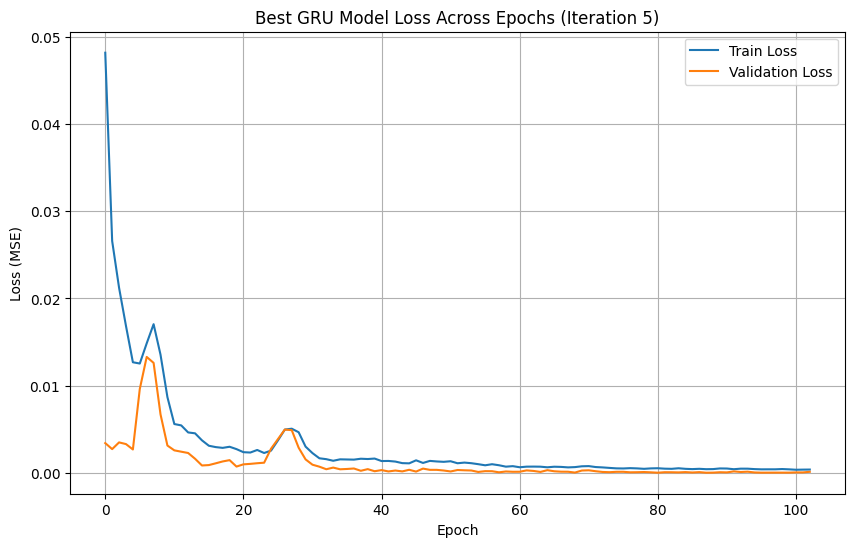

In [ ]:
num_iterations = 5
best_gru_val_mse = float('inf')
best_gru_model = None
best_gru_history = None
best_gru_iteration = -1

# Define the input shape for the GRU model
gru_input_shape = (X_trend_train_windowed.shape[1], X_trend_train_windowed.shape[2])

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_gru(
        X_trend_train_windowed, y_trend_train_windowed,
        X_trend_val_windowed, y_trend_val_windowed,
        gru_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_gru_val_mse:
        best_gru_val_mse = current_val_mse
        best_gru_model = model
        best_gru_history = history
        best_gru_iteration = i + 1
        print(f"New best model found at iteration {best_gru_iteration} with Validation MSE: {best_gru_val_mse:.6f}")

print(f"\n--- Best Model (Iteration {best_gru_iteration}) ---")

# Save the weights of the best model
best_gru_model_weights_path = 'best_gru_trend_model_weights.weights.h5'
best_gru_model.save_weights(best_gru_model_weights_path)
print(f"Best model weights saved to {best_gru_model_weights_path}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_gru_history.history['loss'], label='Train Loss')
plt.plot(best_gru_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best GRU Model Loss Across Epochs (Iteration {best_gru_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### LSTM

In [ ]:
def train_evaluate_lstm(X_train, y_train, X_val, y_val, input_shape, units=50, dropout_rate=0.2, learning_rate=None):
    model = Sequential([
      tf.keras.Input(shape=input_shape),
      LSTM(units=units),
      Dropout(dropout_rate),
      Dense(units=1),
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if learning_rate else 'adam'
    model.compile(optimizer=optimizer, loss='mse')

    early_stopping = EarlyStopping(patience=15, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=False,
    )

    return model, history

print("Defined train_evaluate_lstm function.")

Defined train_evaluate_lstm function.



--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.000200

--- Training Iteration 2/5 ---

--- Training Iteration 3/5 ---

--- Training Iteration 4/5 ---

--- Training Iteration 5/5 ---
New best model found at iteration 5 with Validation MSE: 0.000085

--- Best Model (Iteration 5) ---
Best model weights saved to best_lstm_trend_model_weights.weights.h5


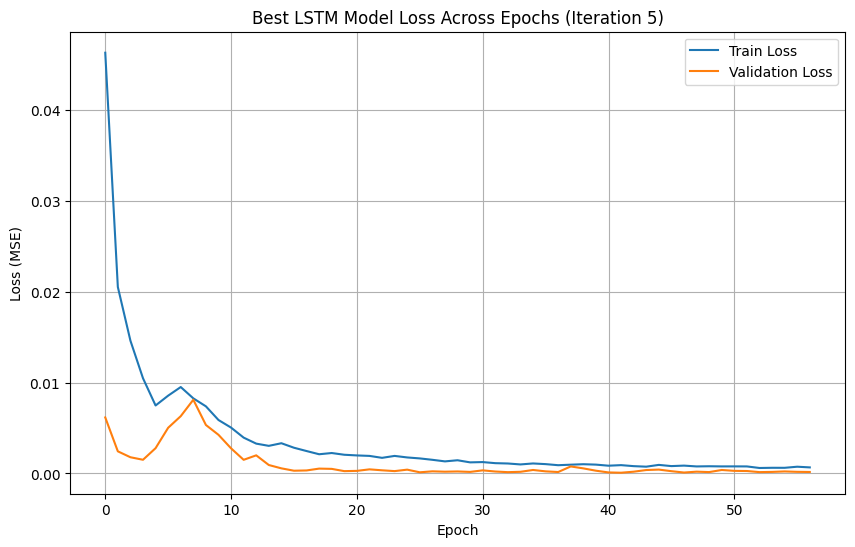

In [ ]:
best_lstm_val_mse = float('inf')
best_lstm_model = None
best_lstm_history = None
best_lstm_iteration = -1

# Define the input shape for the LSTM model
lstm_input_shape = (X_trend_train_windowed.shape[1], X_trend_train_windowed.shape[2])

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_lstm(
        X_trend_train_windowed, y_trend_train_windowed,
        X_trend_val_windowed, y_trend_val_windowed,
        lstm_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_lstm_val_mse:
        best_lstm_val_mse = current_val_mse
        best_lstm_model = model
        best_lstm_history = history
        best_lstm_iteration = i + 1
        print(f"New best model found at iteration {best_lstm_iteration} with Validation MSE: {best_lstm_val_mse:.6f}")

print(f"\n--- Best Model (Iteration {best_lstm_iteration}) ---")

# Save the weights of the best model
best_lstm_model_weights_path = 'best_lstm_trend_model_weights.weights.h5'
best_lstm_model.save_weights(best_lstm_model_weights_path)
print(f"Best model weights saved to {best_lstm_model_weights_path}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_lstm_history.history['loss'], label='Train Loss')
plt.plot(best_lstm_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best LSTM Model Loss Across Epochs (Iteration {best_lstm_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### NARNET

In [ ]:
# Extract only the target feature from the windowed features for NARNET input
X_trend_train_narnet = X_trend_train_windowed[:, :, X_trend_train.columns.get_loc(target_col)]
X_trend_val_narnet = X_trend_val_windowed[:, :, X_trend_val.columns.get_loc(target_col)]
X_trend_test_narnet = X_trend_test_windowed[:, :, X_trend_test.columns.get_loc(target_col)]

def train_evaluate_narnet(X_train, y_train, X_val, y_val, input_shape, dense_units=[128, 64, 32], dropout_rate=0.2, learning_rate=None):
    model_layers = [
        tf.keras.Input(shape=input_shape)
    ]
    for i, units in enumerate(dense_units):
        model_layers.append(Dense(units, activation='relu'))
        if i < len(dense_units) - 1: # Apply dropout after each Dense layer except the last
            model_layers.append(Dropout(dropout_rate))
    model_layers.append(Dense(1))

    model = Sequential(model_layers)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if learning_rate else 'adam'
    model.compile(optimizer=optimizer, loss='mse')

    early_stopping = EarlyStopping(patience=15, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=False,
    )

    return model, history

print("Defined train_evaluate_narnet function.")

Defined train_evaluate_narnet function.



--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.001237

--- Training Iteration 2/5 ---
New best model found at iteration 2 with Validation MSE: 0.000868

--- Training Iteration 3/5 ---

--- Training Iteration 4/5 ---

--- Training Iteration 5/5 ---
New best model found at iteration 5 with Validation MSE: 0.000681

--- Best Model (Iteration 5) ---
Best model weights saved to best_narnet_trend_model_weights.weights.h5


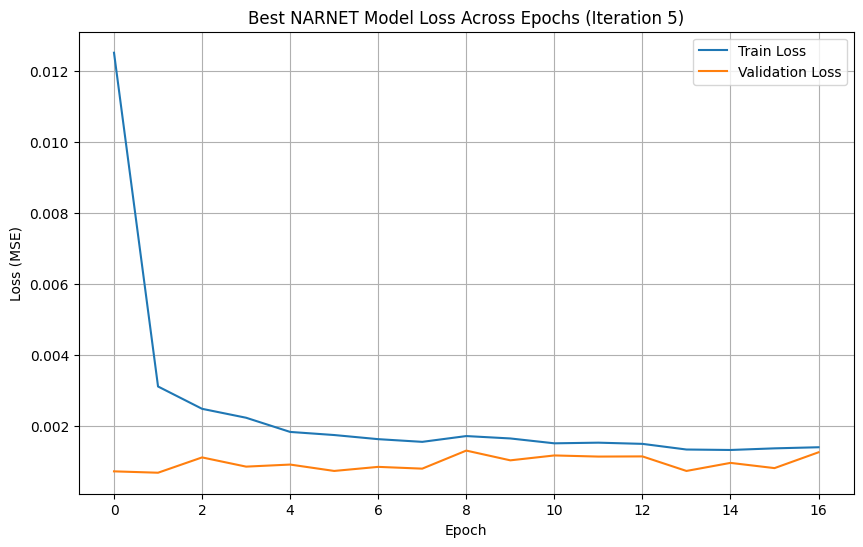

In [ ]:
best_narnet_val_mse = float('inf')
best_narnet_model = None
best_narnet_history = None
best_narnet_iteration = -1

# Define the input shape for the GRU model
narnet_input_shape = (trend_look_back,)

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_narnet(
        X_trend_train_narnet, y_trend_train_windowed,
        X_trend_val_narnet, y_trend_val_windowed,
        narnet_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_narnet_val_mse:
        best_narnet_val_mse = current_val_mse
        best_narnet_model = model
        best_narnet_history = history
        best_narnet_iteration = i + 1
        print(f"New best model found at iteration {best_narnet_iteration} with Validation MSE: {best_narnet_val_mse:.6f}")

print(f"\n--- Best Model (Iteration {best_narnet_iteration}) ---")

# Save the weights of the best model
best_narnet_model_weights_path = 'best_narnet_trend_model_weights.weights.h5'
best_narnet_model.save_weights(best_narnet_model_weights_path)
print(f"Best model weights saved to {best_narnet_model_weights_path}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_narnet_history.history['loss'], label='Train Loss')
plt.plot(best_narnet_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best NARNET Model Loss Across Epochs (Iteration {best_narnet_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Select Best Model

The best model for trend prediction is GRU with Validation MSE: 0.000037
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Trend Test MSE (GRU): 0.000600


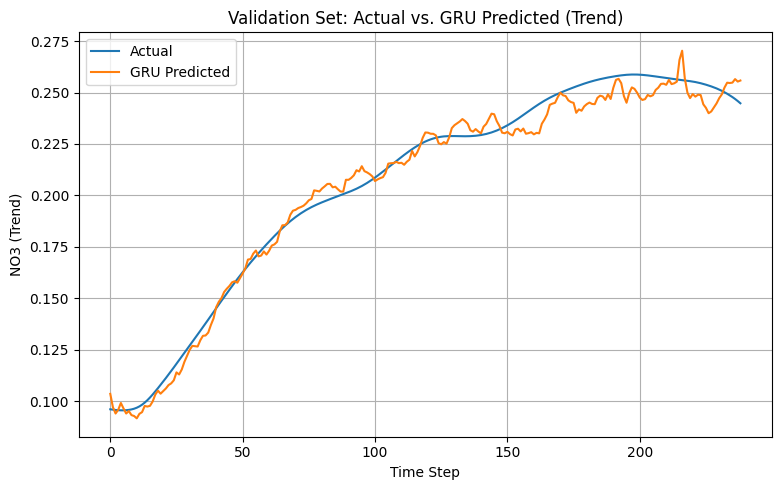

In [ ]:
trend_models = [
    ("GRU", best_gru_model, best_gru_val_mse),
    ("LSTM", best_lstm_model, best_lstm_val_mse),
    ("NARNET", best_narnet_model, best_narnet_val_mse),
]

best_trend_model_name, best_trend_model, best_trend_val_mse = min(trend_models, key=lambda x: x[2])
print(f"The best model for trend prediction is {best_trend_model_name} with Validation MSE: {best_trend_val_mse:.6f}")

# Prepare prediction inputs based on the chosen model
if best_trend_model_name == "NARNET":
    X_val_for_predict = X_trend_val_narnet
    X_test_for_predict = X_trend_test_narnet
elif best_trend_model_name == "GRU" or best_trend_model_name == "LSTM":
    X_val_for_predict = X_trend_val_windowed
    X_test_for_predict = X_trend_test_windowed
else:
    raise ValueError(f"Unknown best model for seasonal prediction: {best_trend_model_name}")

# generate predictions for val and train set
# save the predictions
y_trend_val_pred = best_trend_model.predict(X_val_for_predict)
np.save("y_trend_val_pred.npy", y_trend_val_pred)

y_trend_test_pred = best_trend_model.predict(X_test_for_predict)
trend_test_mse = mean_squared_error(y_trend_test_windowed, y_trend_test_pred)
print(f"Trend Test MSE ({best_trend_model_name}): {trend_test_mse:.6f}")
np.save("y_trend_test_pred.npy", y_trend_test_pred)

# Plot predictions vs actual for validation and test sets
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(y_trend_val_windowed, label="Actual")
plt.plot(y_trend_val_pred, label=f"{best_trend_model_name} Predicted")
plt.title(f"Validation Set: Actual vs. {best_trend_model_name} Predicted (Trend)")
plt.xlabel("Time Step")
plt.ylabel("NO3 (Trend)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Hyperparam Tuning

#### Random Search

In [ ]:
n_trials = 20

def random_search(model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape=None):
    best_val_mse = float('inf')
    best_model = None
    best_params = None
    best_iteration = -1

    start_time = time.time() # Record start time

    print(f"--- Starting Random Search for {model_name} with {n_trials} iterations ---")

    for i in range(n_trials):
        print(f"\n--- Random Search Iteration {i+1}/{n_trials} for {model_name} ---")
        # Randomly sample hyperparameters
        sampled_params = {}
        for param, values in hp_space.items():
            # Handle nested lists for 'dense_units' in MLP/NARNET or special cases like 'hidden_layer_sizes'
            if isinstance(values[0], list):
                # Sample a list of units, e.g., for [64], [64, 32], etc.
                sampled_params[param] = random.choice(values)
            else:
                sampled_params[param] = random.choice(values)

        print(f"Testing with params: {sampled_params}")

        # Train and evaluate model
        if input_shape is not None:
            model, history = train_func(
                X_train, y_train,
                X_val, y_val,
                input_shape,
                **sampled_params
            )
        else:
            # For scikit-learn models like RF, XGBoost, SVR that don't need input_shape
            model, history = train_func(
                X_train, y_train,
                X_val, y_val,
                **sampled_params
            )

        current_val_mse = history['val_loss'] if isinstance(history, dict) else min(history.history['val_loss'])

        if current_val_mse < best_val_mse:
            best_val_mse = current_val_mse
            best_model = model
            best_params = sampled_params
            best_iteration = i + 1
            print(f"New best model found at iteration {best_iteration} with Validation MSE: {best_val_mse:.6f}")

    end_time = time.time() # Record end time
    elapsed_time = end_time - start_time

    print(f"\n--- Best {model_name} Model from Random Search (Iteration {best_iteration}) ---")
    print(f"Best Validation MSE: {best_val_mse:.6f}")
    print(f"Best Parameters: {best_params}")
    print(f"Total Random Search time: {elapsed_time:.2f} seconds")

    return best_model, best_params, best_val_mse, elapsed_time

#### Grid Search

In [ ]:
def grid_search(model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape=None):
    best_val_mse = float('inf')
    best_model = None
    best_params = None
    current_iteration = 0

    # Generate all combinations of hyperparameters
    keys = hp_space.keys()
    values = hp_space.values()
    hyperparameter_combinations = list(itertools.product(*values))

    start_time = time.time() # Record start time

    print(f"--- Starting Grid Search for {model_name} with {len(hyperparameter_combinations)} iterations ---")

    for combo in hyperparameter_combinations:
        current_iteration += 1
        sampled_params = dict(zip(keys, combo))

        print(f"\n--- Grid Search Iteration {current_iteration}/{len(hyperparameter_combinations)} for {model_name} ---")
        print(f"Testing with params: {sampled_params}")

        # Train and evaluate model
        if input_shape is not None:
            model, history = train_func(
                X_train, y_train,
                X_val, y_val,
                input_shape,
                **sampled_params
            )
        else:
            # For scikit-learn models like RF, XGBoost, SVR that don't need input_shape
            model, history = train_func(
                X_train, y_train,
                X_val, y_val,
                **sampled_params
            )

        current_val_mse = history['val_loss'] if isinstance(history, dict) else min(history.history['val_loss'])

        if current_val_mse < best_val_mse:
            best_val_mse = current_val_mse
            best_model = model
            best_params = sampled_params
            print(f"New best model found with Validation MSE: {best_val_mse:.6f}")

    end_time = time.time() # Record end time
    elapsed_time = end_time - start_time

    print(f"\n--- Best {model_name} Model from Grid Search ---")
    print(f"Best Validation MSE: {best_val_mse:.6f}")
    print(f"Best Parameters: {best_params}")
    print(f"Total Grid Search time: {elapsed_time:.2f} seconds")

    return best_model, best_params, best_val_mse, elapsed_time

#### WOA

In [ ]:
num_whales = 4
woa_max_iterations = 5
b = 1

def woa_search(model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape=None):
    best_val_mse = float('inf')
    best_model = None
    best_params = None
    best_iteration = -1 # To track when the best model was found

    # 1. Define search space boundaries and mapping for hyperparameters
    hp_keys = list(hp_space.keys())
    hp_bounds = [(0, len(hp_space[key]) - 1) for key in hp_keys]

    def map_whale_position_to_params(whale_position):
        """Maps continuous whale position (indices) to actual hyperparameter values."""
        params = {}
        for i, key in enumerate(hp_keys):
            # Clip and round the continuous position to get a valid index
            idx = int(round(np.clip(whale_position[i], hp_bounds[i][0], hp_bounds[i][1])))
            params[key] = hp_space[key][idx]
        return params

    # 2. Initialize whale population randomly within bounds
    num_hps = len(hp_keys)
    whales = np.zeros((num_whales, num_hps))
    for i in range(num_whales):
        for j in range(num_hps):
            whales[i, j] = np.random.uniform(hp_bounds[j][0], hp_bounds[j][1])

    fitness = np.array([float('inf')] * num_whales)
    best_whale_position = None
    current_best_model = None # Stores the actual model object

    start_time = time.time() # Record start time

    print(f"--- Starting WOA for {model_name} with {num_whales} whales and {woa_max_iterations} iterations ---")

    for iteration in range(woa_max_iterations):
        print(f"\n--- WOA Iteration {iteration+1}/{woa_max_iterations} ---")

        # Update 'a' parameter for WOA (linearly decreases from 2 to 0)
        a_param = 2 - iteration * (2 / woa_max_iterations)

        for i in range(num_whales):
            current_params = map_whale_position_to_params(whales[i])

            try:
                # Train and evaluate model
                if input_shape is not None:
                    model, history = train_func(X_train, y_train, X_val, y_val, input_shape, **current_params)
                else:
                    model, history = train_func(X_train, y_train, X_val, y_val, **current_params)

                current_val_mse = history['val_loss'] if isinstance(history, dict) else min(history.history['val_loss'])
                fitness[i] = current_val_mse

                if current_val_mse < best_val_mse:
                    best_val_mse = current_val_mse
                    best_params = current_params
                    best_whale_position = whales[i].copy()
                    current_best_model = model
                    best_iteration = iteration + 1
                    print(f"  New global best found at iteration {iteration+1}, whale {i+1} with Validation MSE: {best_val_mse:.6f}")

            except Exception as e:
                print(f"  Error training model for whale {i+1} with params {current_params}: {e}")
                fitness[i] = float('inf') # Assign infinite fitness to penalize errors

        if best_whale_position is None: # If no successful model training yet, cannot update positions meaningfully
            print("  No successful model training yet, skipping whale position update for this iteration.")
            continue

        # Update whale positions based on WOA algorithm
        for i in range(num_whales):
            r1, r2 = np.random.rand(2) # Random vectors for A and C
            A = 2 * a_param * r1 - a_param
            C = 2 * r2
            l = np.random.uniform(-1, 1) # Random value for spiral equation
            p = np.random.rand() # Probability for choice between spiral and shrinking encircling

            D_distance = np.abs(best_whale_position - whales[i]) # Distance to the best whale

            if p < 0.5:
                if np.abs(A) < 1: # Shrinking encircling prey
                    D_prime = np.abs(C * best_whale_position - whales[i])
                    whales[i] = best_whale_position - A * D_prime
                else: # Searching for prey (exploration phase)
                    # Select a random whale from the current population
                    rand_whale_idx = np.random.randint(num_whales)
                    X_rand = whales[rand_whale_idx]
                    D = np.abs(C * X_rand - whales[i])
                    whales[i] = X_rand - A * D
            else:
                # Spiral updating position
                whales[i] = D_distance * np.exp(b * l) * np.cos(2 * np.pi * l) + best_whale_position

            # Apply bounds to whale positions (hyperparameter indices)
            for j in range(num_hps):
                whales[i][j] = np.clip(whales[i][j], hp_bounds[j][0], hp_bounds[j][1])

    end_time = time.time() # Record end time
    elapsed_time = end_time - start_time

    print(f"\n--- Best {model_name} Model from WOA Search (Iteration {best_iteration}) ---")
    print(f"Best Validation MSE: {best_val_mse:.6f}")
    print(f"Best Parameters: {best_params}")
    print(f"Total WOA time: {elapsed_time:.2f} seconds")

    return current_best_model, best_params, best_val_mse, elapsed_time

#### Tuning with Every Method

In [ ]:
trend_models_to_tune = [
    ("GRU", train_evaluate_gru, gru_hyperparameter_space, X_trend_train_windowed,
     y_trend_train_windowed, X_trend_val_windowed, y_trend_val_windowed, gru_input_shape),

    ("LSTM", train_evaluate_lstm, lstm_hyperparameter_space, X_trend_train_windowed,
     y_trend_train_windowed, X_trend_val_windowed, y_trend_val_windowed, lstm_input_shape),

    ("NARNET", train_evaluate_narnet, narnet_hyperparameter_space, X_trend_train_narnet,
     y_trend_train_windowed, X_trend_val_narnet, y_trend_val_windowed, narnet_input_shape)
]

best_rf_trend_tuned_model = None
best_rf_trend_tuned_val_mse = float('inf')
best_rf_trend_tuned_params = None
rf_trend_time = 0

best_gs_trend_tuned_model = None
best_gs_trend_tuned_val_mse = float('inf')
best_gs_trend_tuned_params = None
gs_trend_time = 0

best_woa_trend_tuned_model = None
best_woa_trend_tuned_val_mse = float('inf')
best_woa_trend_tuned_params = None
woa_trend_time = 0

# only tune the best model from the selection
for model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape in trend_models_to_tune:
    if model_name == best_trend_model_name:
        best_rf_trend_tuned_model, best_rf_trend_tuned_params, best_rf_trend_tuned_val_mse, rf_trend_time = random_search(
            model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape
        )

--- Starting Random Search for GRU with 20 iterations ---

--- Random Search Iteration 1/20 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.005}
New best model found at iteration 1 with Validation MSE: 0.000115

--- Random Search Iteration 2/20 for GRU ---
Testing with params: {'units': 64, 'dropout_rate': 0.1, 'learning_rate': 0.005}
New best model found at iteration 2 with Validation MSE: 0.000044

--- Random Search Iteration 3/20 for GRU ---
Testing with params: {'units': 128, 'dropout_rate': 0.1, 'learning_rate': 0.0005}

--- Random Search Iteration 4/20 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.005}

--- Random Search Iteration 5/20 for GRU ---
Testing with params: {'units': 64, 'dropout_rate': 0.1, 'learning_rate': 0.0005}

--- Random Search Iteration 6/20 for GRU ---
Testing with params: {'units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0005}

--- Random Search Iteration 7/20 for GRU ---
Test

In [ ]:
for model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape in trend_models_to_tune:
    if model_name == best_trend_model_name:
        best_gs_trend_tuned_model, best_gs_trend_tuned_params, best_gs_trend_tuned_val_mse, gs_trend_time = grid_search(
            model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape
        )

--- Starting Grid Search for GRU with 27 iterations ---

--- Grid Search Iteration 1/27 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.1, 'learning_rate': 0.005}
New best model found with Validation MSE: 0.000054

--- Grid Search Iteration 2/27 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.1, 'learning_rate': 0.001}

--- Grid Search Iteration 3/27 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.1, 'learning_rate': 0.0005}

--- Grid Search Iteration 4/27 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.005}

--- Grid Search Iteration 5/27 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001}

--- Grid Search Iteration 6/27 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.0005}

--- Grid Search Iteration 7/27 for GRU ---
Testing with params: {'units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.005}

--- Grid Search Iterat

In [ ]:
for model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape in trend_models_to_tune:
    if model_name == best_trend_model_name:
        best_woa_trend_tuned_model, best_woa_trend_tuned_, best_woa_trend_tuned_val_mse, woa_trend_time = woa_search(
            model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape
        )

--- Starting WOA for GRU with 4 whales and 5 iterations ---

--- WOA Iteration 1/5 ---
  New global best found at iteration 1, whale 1 with Validation MSE: 0.001563
  New global best found at iteration 1, whale 2 with Validation MSE: 0.000280
  New global best found at iteration 1, whale 4 with Validation MSE: 0.000110

--- WOA Iteration 2/5 ---
  New global best found at iteration 2, whale 2 with Validation MSE: 0.000040

--- WOA Iteration 3/5 ---

--- WOA Iteration 4/5 ---

--- WOA Iteration 5/5 ---
  New global best found at iteration 5, whale 3 with Validation MSE: 0.000039

--- Best GRU Model from WOA Search (Iteration 5) ---
Best Validation MSE: 0.000039
Best Parameters: {'units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.001}
Total WOA time: 283.53 seconds


### Determine if Tuned Model is Better

In [ ]:
def compare_models(
    model_name, tuned_model, original_model, tuned_model_val_mse, original_model_val_mse,
    y_val_windowed, y_test_windowed, y_val_pred, y_test_pred, tuning_name
):

    if tuned_model_val_mse < original_model_val_mse:
        print("Tuned model is better than the original model.")
        print(f"Original Model Validation MSE: {original_model_val_mse:.6f}")
        print(f"Tuned Model Validation MSE: {tuned_model_val_mse:.6f}")

        print("Best model is now the tuned model.")

        # generate predictions for val and test set
        y_val_pred_tuned = tuned_model.predict(X_val_for_predict)

        y_test_pred_tuned = tuned_model.predict(X_test_for_predict)
        test_mse_tuned = mean_squared_error(y_test_windowed, y_test_pred_tuned)
        print(f" Test MSE ({model_name} - Tuned): {test_mse_tuned:.6f}")

        # Plot predictions vs actual for validation and test sets
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 2, 1)
        plt.plot(y_val_windowed, label="Actual")
        plt.plot(y_val_pred_tuned, label=f"{model_name} Tuned Predicted ({tuning_name})")
        plt.title(f"Validation Set: Actual vs. {model_name} Tuned Predicted ({tuning_name})")
        plt.xlabel("Time Step")
        plt.ylabel(f"NO3")
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(y_test_windowed, label="Actual")
        plt.plot(y_test_pred_tuned, label=f"{model_name} Tuned Predicted ({tuning_name})")
        plt.title(f"Test Set: Actual vs. {model_name} Tuned Predicted ({tuning_name})")
        plt.xlabel("Time Step")
        plt.ylabel(f"NO3")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        return y_val_pred_tuned, y_test_pred_tuned, tuned_model_val_mse

    else:
        print("Tuned model is not better than the original model.")
        print(f"Original Model Validation MSE: {original_model_val_mse:.6f}")
        print(f"Tuned Model Validation MSE: {tuned_model_val_mse:.6f}")

        return y_val_pred, y_test_pred, original_model_val_mse

In [ ]:
y_trend_val_pred_rf_tuned = None
y_trend_test_pred_rf_tuned = None
trend_val_mse_rf_tuned = None

y_trend_val_pred_gs_tuned = None
y_trend_test_pred_gs_tuned = None
trend_val_mse_gs_tuned = None

y_trend_val_pred_woa_tuned = None
y_trend_test_pred_woa_tuned = None
trend_val_mse_woa_tuned = None

val_mse_comparison_data = []

print("--- Tuned Model Using Random Search ---")
y_trend_val_pred_rf_tuned, y_trend_test_pred_rf_tuned, trend_val_mse_rf_tuned = compare_models(
    best_trend_model_name, best_rf_trend_tuned_model, best_trend_model, best_rf_trend_tuned_val_mse, best_trend_val_mse,
    y_trend_val_windowed, y_trend_test_windowed, y_trend_val_pred, y_trend_test_pred, "Random Search"
)
val_mse_comparison_data.append({"Model": f"{best_trend_model_name} (Random Search)", "Validation MSE": trend_val_mse_rf_tuned, "Time Taken (s)": rf_trend_time})

print("\n--- Tuned Model Using Grid Search ---")
y_trend_val_pred_gs_tuned, y_trend_test_pred_gs_tuned, trend_val_mse_gs_tuned = compare_models(
    best_trend_model_name, best_gs_trend_tuned_model, best_trend_model, best_gs_trend_tuned_val_mse, best_trend_val_mse,
    y_trend_val_windowed, y_trend_test_windowed, y_trend_val_pred, y_trend_test_pred, "Grid Search"
)
val_mse_comparison_data.append({"Model": f"{best_trend_model_name} (Grid Search)", "Validation MSE": trend_val_mse_gs_tuned, "Time Taken (s)": gs_trend_time})

print("\n--- Tuned Model Using WOA ---")
y_trend_val_pred_woa_tuned, y_trend_test_pred_woa_tuned, trend_val_mse_woa_tuned = compare_models(
    best_trend_model_name, best_woa_trend_tuned_model, best_trend_model, best_woa_trend_tuned_val_mse, best_trend_val_mse,
    y_trend_val_windowed, y_trend_test_windowed, y_trend_val_pred, y_trend_test_pred, "WOA"
)
val_mse_comparison_data.append({"Model": f"{best_trend_model_name} (WOA)", "Validation MSE": trend_val_mse_woa_tuned, "Time Taken (s)": woa_trend_time})


comparison_df = pd.DataFrame(val_mse_comparison_data)
comparison_df = comparison_df.sort_values(by="Validation MSE")
print("\n--- Tuned Trend Model Validation MSE Comparison ---")
display(comparison_df)

--- Tuned Model Using Random Search ---
Tuned model is not better than the original model.
Original Model Validation MSE: 0.000037
Tuned Model Validation MSE: 0.000037

--- Tuned Model Using Grid Search ---
Tuned model is not better than the original model.
Original Model Validation MSE: 0.000037
Tuned Model Validation MSE: 0.000046

--- Tuned Model Using WOA ---
Tuned model is not better than the original model.
Original Model Validation MSE: 0.000037
Tuned Model Validation MSE: 0.000039

--- Tuned Trend Model Validation MSE Comparison ---


,Model,Validation MSE,Time Taken (s)
0,GRU (Random Search),0.000037,243.757986
1,GRU (Grid Search),0.000037,353.529988
2,GRU (WOA),0.000037,283.527030


## Seasonal

### NARNET

In [ ]:
# Extract only the target feature from the windowed features for NARNET input
X_season_train_narnet = X_season_train_windowed[:, :, X_season_train.columns.get_loc(target_col)]
X_season_val_narnet = X_season_val_windowed[:, :, X_season_val.columns.get_loc(target_col)]
X_season_test_narnet = X_season_test_windowed[:, :, X_season_test.columns.get_loc(target_col)]


--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.000014

--- Training Iteration 2/5 ---
New best model found at iteration 2 with Validation MSE: 0.000013

--- Training Iteration 3/5 ---

--- Training Iteration 4/5 ---

--- Training Iteration 5/5 ---

--- Best Model (Iteration 2) ---
Best model weights saved to best_narnet_season_model_weights.weights.h5


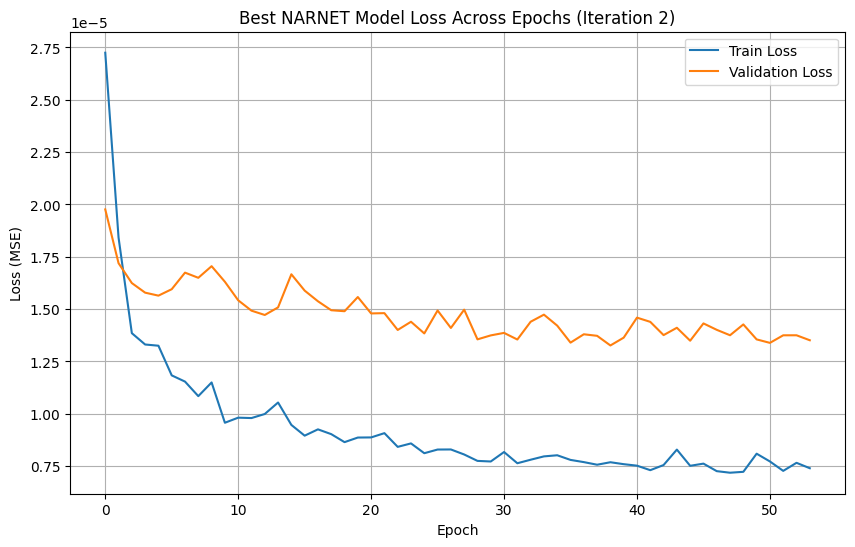

In [ ]:
best_narnet_val_mse = float('inf')
best_narnet_model = None
best_narnet_history = None
best_narnet_iteration = -1

# Define the input shape for the GRU model
narnet_input_shape = (season_look_back,)

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_narnet(
        X_season_train_narnet, y_season_train_windowed,
        X_season_val_narnet, y_season_val_windowed,
        narnet_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_narnet_val_mse:
        best_narnet_val_mse = current_val_mse
        best_narnet_model = model
        best_narnet_history = history
        best_narnet_iteration = i + 1
        print(f"New best model found at iteration {best_narnet_iteration} with Validation MSE: {best_narnet_val_mse:.6f}")

print(f"\n--- Best Model (Iteration {best_narnet_iteration}) ---")

# Save the weights of the best model
best_narnet_model_weights_path = 'best_narnet_season_model_weights.weights.h5'
best_narnet_model.save_weights(best_narnet_model_weights_path)
print(f"Best model weights saved to {best_narnet_model_weights_path}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_narnet_history.history['loss'], label='Train Loss')
plt.plot(best_narnet_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best NARNET Model Loss Across Epochs (Iteration {best_narnet_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Linear Regression

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_season_train_flattened, y_season_train_windowed)
print("Linear Regression model trained.")

y_linear_val_pred = linear_model.predict(X_season_val_flattened)

val_mse_linear = mean_squared_error(y_season_val_windowed, y_linear_val_pred)
print(f"\nLinear Regression Validation MSE: {val_mse_linear:.6f}")

Linear Regression model trained.

Linear Regression Validation MSE: 0.000008


### MLP

In [ ]:
def train_evaluate_mlp(X_train, y_train, X_val, y_val, input_shape, hidden_layer_sizes = [128, 64, 32], dropout_rate = 0.2, learning_rate=None):
    model_layers = [
        tf.keras.Input(shape=input_shape)
    ]
    for i, units in enumerate(hidden_layer_sizes):
        model_layers.append(Dense(units, activation='relu'))
        if i < len(hidden_layer_sizes) - 1: # Apply dropout after each Dense layer except the last
            model_layers.append(Dropout(dropout_rate))
    model_layers.append(Dense(1))

    model = Sequential(model_layers)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if learning_rate else 'adam'
    model.compile(optimizer=optimizer, loss='mse')

    early_stopping = EarlyStopping(patience=15, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=False,
    )

    return model, history

print("Defined train_evaluate_mlp function.")

Defined train_evaluate_mlp function.



--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.000052

--- Training Iteration 2/5 ---

--- Training Iteration 3/5 ---
New best model found at iteration 3 with Validation MSE: 0.000052

--- Training Iteration 4/5 ---
New best model found at iteration 4 with Validation MSE: 0.000051

--- Training Iteration 5/5 ---
New best model found at iteration 5 with Validation MSE: 0.000051

--- Best Model (Iteration 5) ---
Best model weights saved to best_mlp_season_model_weights.weights.h5


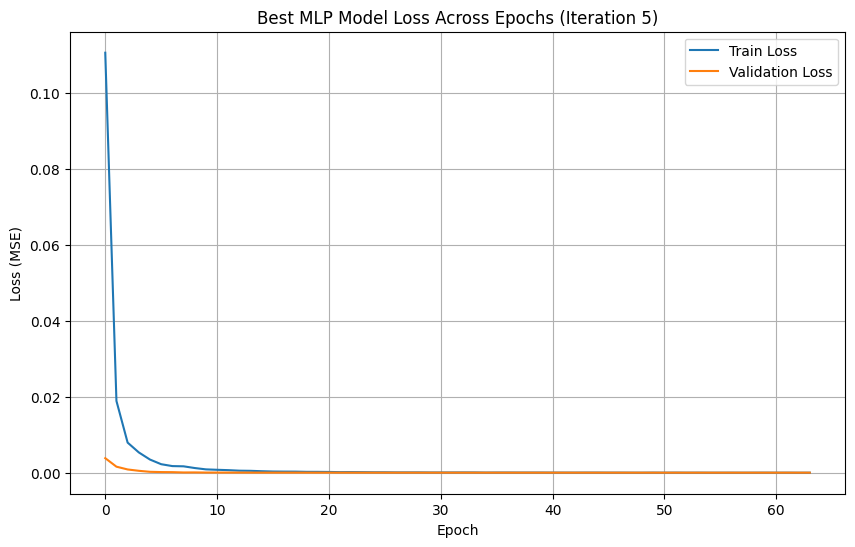

In [ ]:
best_mlp_val_mse = float('inf')
best_mlp_model = None
best_mlp_history = None
best_mlp_iteration = -1

# Define the input shape for the MLP model
mlp_input_shape = (X_season_train_flattened.shape[1],)

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_mlp(
        X_season_train_flattened, y_season_train_windowed,
        X_season_val_flattened, y_season_val_windowed,
        mlp_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_mlp_val_mse:
        best_mlp_val_mse = current_val_mse
        best_mlp_model = model
        best_mlp_history = history
        best_mlp_iteration = i + 1
        print(f"New best model found at iteration {best_mlp_iteration} with Validation MSE: {best_mlp_val_mse:.6f}")

print(f"\n--- Best Model (Iteration {best_mlp_iteration}) ---")

# Save the weights of the best model
best_mlp_model_weights_path = 'best_mlp_season_model_weights.weights.h5'
best_mlp_model.save_weights(best_mlp_model_weights_path)
print(f"Best model weights saved to {best_mlp_model_weights_path}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_mlp_history.history['loss'], label='Train Loss')
plt.plot(best_mlp_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best MLP Model Loss Across Epochs (Iteration {best_mlp_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Select Best Model

The best model for seasonal prediction is Linear Regression with Validation MSE: 0.000008
Seasonal Test MSE (Linear Regression): 0.000775
Seasonal Test RMSE (Linear Regression): 0.027839
Seasonal Test R2 (Linear Regression): 0.665889
Seasonal Test MAE (Linear Regression): 0.012814


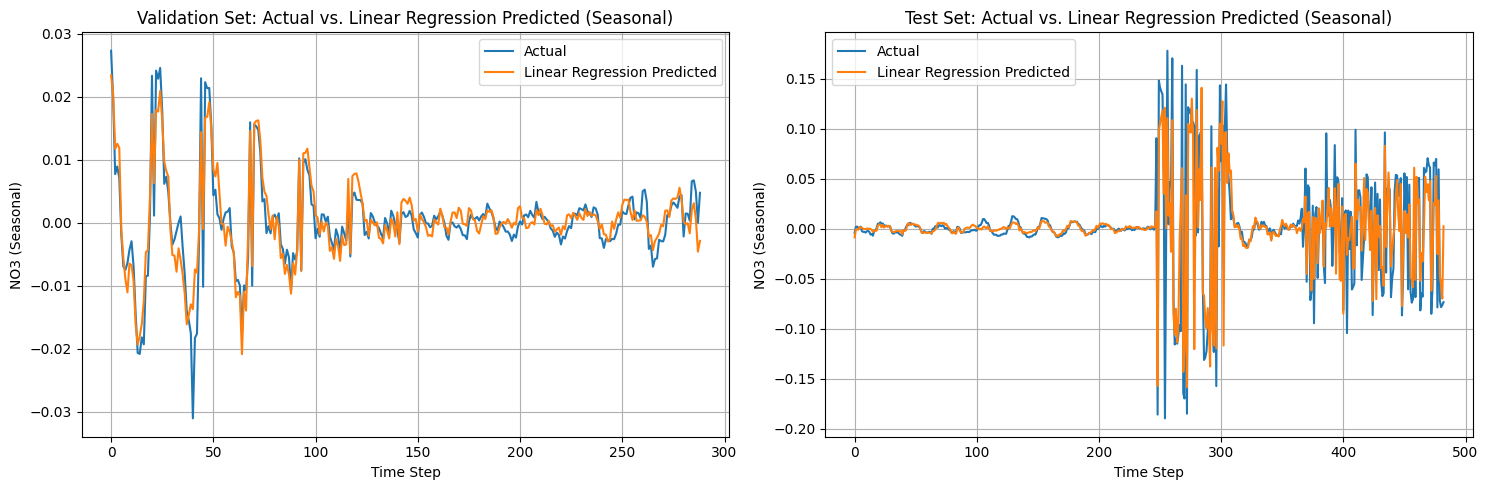

In [ ]:
season_models = [
    ("NARNET", best_narnet_model, best_narnet_val_mse),
    ("Linear Regression", linear_model, val_mse_linear),
    ("MLP", best_mlp_model, best_mlp_val_mse)
]

best_season_model_name, best_season_model, best_season_val_mse = min(season_models, key=lambda x: x[2])
print(f"The best model for seasonal prediction is {best_season_model_name} with Validation MSE: {best_season_val_mse:.6f}")

# Prepare prediction inputs based on the chosen model
if best_season_model_name == "NARNET":
    X_val_for_predict = X_season_val_narnet
    X_test_for_predict = X_season_test_narnet
elif best_season_model_name == "Linear Regression" or best_season_model_name == "MLP":
    X_val_for_predict = X_season_val_flattened
    X_test_for_predict = X_season_test_flattened
else:
    raise ValueError(f"Unknown best model for seasonal prediction: {best_season_model_name}")

# generate predictions for val and train set
# save the predictions
y_season_val_pred = best_season_model.predict(X_val_for_predict)
np.save("y_season_val_pred.npy", y_season_val_pred)

y_season_test_pred = best_season_model.predict(X_test_for_predict)
season_test_mse, season_test_rmse, season_test_r2, season_test_mae = calc_metrics(y_season_test_windowed, y_season_test_pred)
print(f"Seasonal Test MSE ({best_season_model_name}): {season_test_mse:.6f}")
print(f"Seasonal Test RMSE ({best_season_model_name}): {season_test_rmse:.6f}")
print(f"Seasonal Test R2 ({best_season_model_name}): {season_test_r2:.6f}")
print(f"Seasonal Test MAE ({best_season_model_name}): {season_test_mae:.6f}")
np.save("y_season_test_pred.npy", y_season_test_pred)

# Plot predictions vs actual for validation and test sets
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(y_season_val_windowed, label="Actual")
plt.plot(y_season_val_pred, label=f"{best_season_model_name} Predicted")
plt.title(f"Validation Set: Actual vs. {best_season_model_name} Predicted (Seasonal)")
plt.xlabel("Time Step")
plt.ylabel("NO3 (Seasonal)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(y_season_test_windowed, label="Actual")
plt.plot(y_season_test_pred, label=f"{best_season_model_name} Predicted")
plt.title(f"Test Set: Actual vs. {best_season_model_name} Predicted (Seasonal)")
plt.xlabel("Time Step")
plt.ylabel("NO3 (Seasonal)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Hyperparam Tuning

In [ ]:
best_rf_season_tuned_model = None
best_rf_season_tuned_val_mse = float('inf')
best_rf_season_tuned_params = None
rf_season_time = 0

best_gs_season_tuned_model = None
best_gs_season_tuned_val_mse = float('inf')
best_gs_season_tuned_params = None
gs_season_time = 0

best_woa_season_tuned_model = None
best_woa_season_tuned_val_mse = float('inf')
best_woa_season_tuned_params = None
woa_season_time = 0

if best_season_model_name != "Linear Regression":

    season_models_to_tune = [
        ("MLP", train_evaluate_mlp, mlp_hyperparameter_space, X_season_train_flattened,
        y_season_train_windowed, X_season_val_flattened, y_season_val_windowed, mlp_input_shape),

        ("NARNET", train_evaluate_narnet, narnet_hyperparameter_space, X_season_train_narnet,
        y_season_train_windowed, X_season_val_narnet, y_season_val_windowed, narnet_input_shape)
    ]

    n_trials = 15

    # only tune the best model from the selection
    for model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape in season_models_to_tune:
        if model_name == best_season_model_name:
            best_gs_season_tuned_model, best_gs_season_tuned_params, best_gs_season_tuned_val_mse, gs_season_time = grid_search(
                model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape
            )

            best_rf_season_tuned_model, best_rf_season_tuned_params, best_rf_season_tuned_val_mse, rf_season_time = random_search(
                model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape
            )

            best_woa_season_tuned_model, best_woa_season_tuned_params, best_woa_season_tuned_val_mse, woa_season_time = woa_search(
                model_name, train_func, hp_space, X_train, y_train, X_val, y_val, input_shape
            )

else:
    print("Linear Regression model does not require hyperparameter tuning.")

Linear Regression model does not require hyperparameter tuning.


### Determine if Tuned Model is Better

In [ ]:
if best_season_model_name != "Linear Regression":

    y_season_val_pred_rf_tuned = None
    y_season_test_pred_rf_tuned = None
    season_val_mse_rf_tuned = None

    y_season_val_pred_gs_tuned = None
    y_season_test_pred_gs_tuned = None
    season_val_mse_gs_tuned = None

    y_season_val_pred_woa_tuned = None
    y_season_test_pred_woa_tuned = None
    season_val_mse_woa_tuned = None

    val_mse_comparison_data = []

    print("--- Tuned Model Using Random Search ---")
    y_season_val_pred_rf_tuned, y_season_test_pred_rf_tuned, season_val_mse_rf_tuned = compare_models(
        best_season_model_name, best_rf_season_tuned_model, best_season_model, best_rf_season_tuned_val_mse, best_season_val_mse,
        y_season_val_windowed, y_season_test_windowed, y_season_val_pred, y_season_test_pred, "Random Search"
    )
    val_mse_comparison_data.append({"Model": f"{best_season_model_name} (Random Search)", "Validation MSE": season_val_mse_rf_tuned, "Time Taken (s)": rf_season_time})

    print("\n--- Tuned Model Using Grid Search ---")
    y_season_val_pred_gs_tuned, y_season_test_pred_gs_tuned, season_val_mse_gs_tuned = compare_models(
        best_season_model_name, best_gs_season_tuned_model, best_season_model, best_gs_season_tuned_val_mse, best_season_val_mse,
        y_season_val_windowed, y_season_test_windowed, y_season_val_pred, y_season_test_pred, "Grid Search"
    )
    val_mse_comparison_data.append({"Model": f"{best_season_model_name} (Grid Search)", "Validation MSE": season_val_mse_gs_tuned, "Time Taken (s)": gs_season_time})

    print("\n--- Tuned Model Using WOA ---")
    y_season_val_pred_woa_tuned, y_season_test_pred_woa_tuned, season_val_mse_woa_tuned = compare_models(
        best_season_model_name, best_woa_season_tuned_model, best_season_model, best_woa_season_tuned_val_mse, best_season_val_mse,
        y_season_val_windowed, y_season_test_windowed, y_season_val_pred, y_season_test_pred, "WOA"
    )
    val_mse_comparison_data.append({"Model": f"{best_season_model_name} (WOA)", "Validation MSE": season_val_mse_woa_tuned, "Time Taken (s)": woa_season_time})


    comparison_df = pd.DataFrame(val_mse_comparison_data)
    comparison_df = comparison_df.sort_values(by="Validation MSE")
    print("\n--- Tuned Seasonal Model Validation MSE Comparison ---")
    display(comparison_df)

else:
    print("Linear Regression model does not require hyperparameter tuning.")

    y_season_val_pred_rf_tuned = y_season_val_pred
    y_season_test_pred_rf_tuned = y_season_test_pred
    season_val_mse_rf_tuned = best_season_val_mse

    y_season_val_pred_gs_tuned = y_season_val_pred
    y_season_test_pred_gs_tuned = y_season_test_pred
    season_val_mse_gs_tuned = best_season_val_mse

    y_season_val_pred_woa_tuned = y_season_val_pred
    y_season_test_pred_woa_tuned = y_season_test_pred
    season_val_mse_woa_tuned = best_season_val_mse

Linear Regression model does not require hyperparameter tuning.


## Residual

### RF

In [ ]:
def train_evaluate_rf(
    X_train, y_train,
    X_val, y_val,
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
):
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42,
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)

    # Simulate Keras history object
    history = {'val_loss': val_mse}

    return model, history

print("Defined train_evaluate_rf function to return history dictionary.")

Defined train_evaluate_rf function to return history dictionary.


In [ ]:
rf_model, rf_history = train_evaluate_rf(
    X_residual_train_flattened, y_residual_train_windowed,
    X_residual_val_flattened, y_residual_val_windowed
)
val_mse_rf = rf_history['val_loss']
print(f"\nRandomForestRegressor Validation MSE: {val_mse_rf:.6f}")


RandomForestRegressor Validation MSE: 0.000195


### XGBoost

In [ ]:
def train_evaluate_xbg(
    X_train, y_train,
    X_val, y_val,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05
):
    model = xgb.XGBRegressor(
      n_estimators=n_estimators,
      max_depth=max_depth,
      learning_rate=learning_rate,
      subsample=0.8,
      colsample_bytree=0.6,
      objective='reg:squarederror',
      n_jobs=-1,
      random_state=42
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)

    # Simulate Keras history object
    history = {'val_loss': val_mse}

    return model, history

print("Defined train_evaluate_xbg function to return history dictionary.")

Defined train_evaluate_xbg function to return history dictionary.


In [ ]:
xgb_model, xgb_history = train_evaluate_xbg(
    X_residual_train_flattened, y_residual_train_windowed,
    X_residual_val_flattened, y_residual_val_windowed
)
val_mse_xgb = xgb_history['val_loss']
print(f"\nXGBoost Regressor Validation MSE: {val_mse_xgb:.6f}")


XGBoost Regressor Validation MSE: 0.000210


### SVR

In [ ]:
def train_evaluate_svr(
    X_train, y_train,
    X_val, y_val,
    C=1.0,
    epsilon=0.05
):
    model = SVR(kernel='rbf', C=C, epsilon=epsilon)

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)

    # Simulate Keras history object
    history = {'val_loss': val_mse}

    return model, history

print("Defined train_evaluate_svr function to return history dictionary.")

Defined train_evaluate_svr function to return history dictionary.


In [ ]:
svr_model, svr_history = train_evaluate_svr(
    X_residual_train_flattened, y_residual_train_windowed,
    X_residual_val_flattened, y_residual_val_windowed
)
val_mse_svr = svr_history['val_loss']
print(f"\nSVR Validation MSE: {val_mse_svr:.6f}")


SVR Validation MSE: 0.000285


### MLP


--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.000198

--- Training Iteration 2/5 ---

--- Training Iteration 3/5 ---
New best model found at iteration 3 with Validation MSE: 0.000198

--- Training Iteration 4/5 ---

--- Training Iteration 5/5 ---

--- Best Model (Iteration 3) ---
Best model weights saved to best_mlp_residual_model_weights.weights.h5


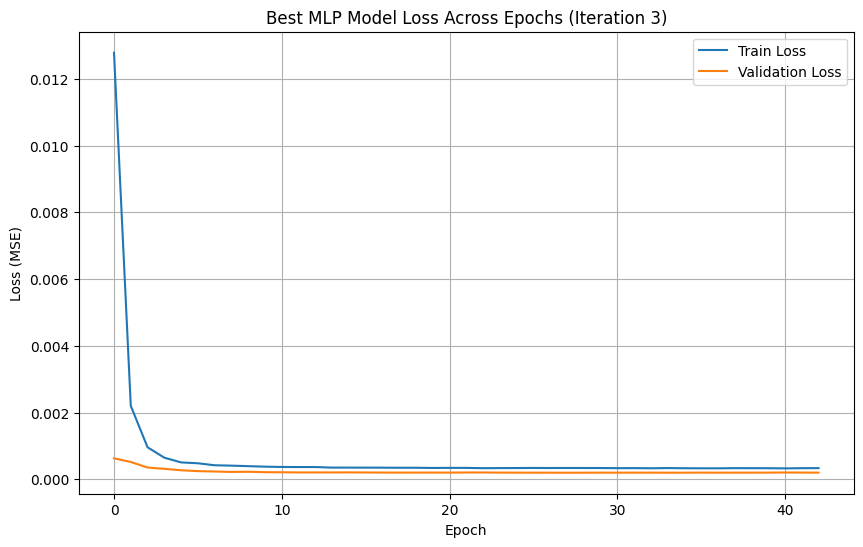

In [ ]:
best_mlp_val_mse = float('inf')
best_mlp_model = None
best_mlp_history = None
best_mlp_iteration = -1

# Define the input shape for the MLP model
mlp_input_shape = (X_residual_train_flattened.shape[1],)

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_mlp(
        X_residual_train_flattened, y_residual_train_windowed,
        X_residual_val_flattened, y_residual_val_windowed,
        mlp_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_mlp_val_mse:
        best_mlp_val_mse = current_val_mse
        best_mlp_model = model
        best_mlp_history = history
        best_mlp_iteration = i + 1
        print(f"New best model found at iteration {best_mlp_iteration} with Validation MSE: {best_mlp_val_mse:.6f}")

print(f"\n--- Best Model (Iteration {best_mlp_iteration}) ---")

# Save the weights of the best model
best_mlp_model_weights_path = 'best_mlp_residual_model_weights.weights.h5'
best_mlp_model.save_weights(best_mlp_model_weights_path)
print(f"Best model weights saved to {best_mlp_model_weights_path}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_mlp_history.history['loss'], label='Train Loss')
plt.plot(best_mlp_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best MLP Model Loss Across Epochs (Iteration {best_mlp_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Select Best Model

The best model for residual prediction is RF with Validation MSE: 0.000195
Residual Test MSE (RF): 0.002325
Residual Test RMSE (RF): 0.048223
Residual Test R2 (RF): 0.019981
Residual Test MAE (RF): 0.022297


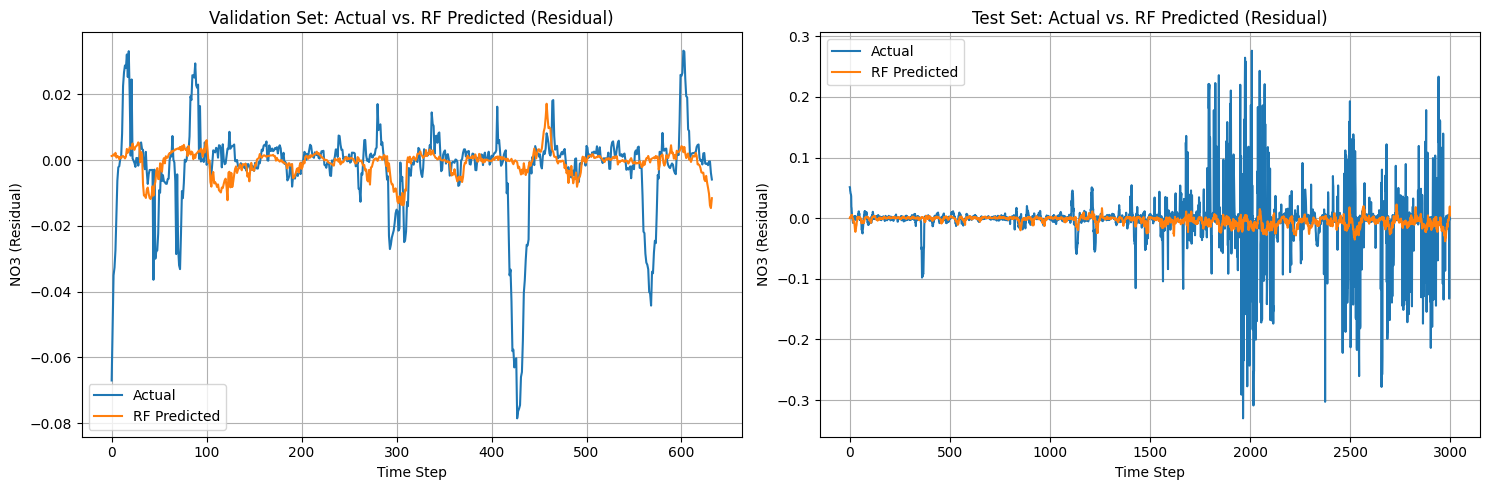

In [ ]:
residual_models = [
    ("RF", rf_model, val_mse_rf),
    ("XGBoost", xgb_model, val_mse_xgb),
    ("SVR", svr_model, val_mse_svr),
    ("MLP", best_mlp_model, best_mlp_val_mse)
]

best_residual_model_name, best_residual_model, best_residual_val_mse = min(residual_models, key=lambda x: x[2])
print(f"The best model for residual prediction is {best_residual_model_name} with Validation MSE: {best_residual_val_mse:.6f}")

X_val_for_predict = X_residual_val_flattened
X_test_for_predict = X_residual_test_flattened

# generate predictions for val and train set
# save the predictions
y_residual_val_pred = best_residual_model.predict(X_val_for_predict)
np.save("y_residual_val_pred.npy", y_residual_val_pred)

y_residual_test_pred = best_residual_model.predict(X_test_for_predict)
residual_test_mse, residual_test_rmse, residual_test_r2, residual_test_mae = calc_metrics(y_residual_test_windowed, y_residual_test_pred)
print(f"Residual Test MSE ({best_residual_model_name}): {residual_test_mse:.6f}")
print(f"Residual Test RMSE ({best_residual_model_name}): {residual_test_rmse:.6f}")
print(f"Residual Test R2 ({best_residual_model_name}): {residual_test_r2:.6f}")
print(f"Residual Test MAE ({best_residual_model_name}): {residual_test_mae:.6f}")
np.save("y_residual_test_pred.npy", y_residual_test_pred)

# Plot predictions vs actual for validation and test sets
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(y_residual_val_windowed, label="Actual")
plt.plot(y_residual_val_pred, label=f"{best_residual_model_name} Predicted")
plt.title(f"Validation Set: Actual vs. {best_residual_model_name} Predicted (Residual)")
plt.xlabel("Time Step")
plt.ylabel("NO3 (Residual)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(y_residual_test_windowed, label="Actual")
plt.plot(y_residual_test_pred, label=f"{best_residual_model_name} Predicted")
plt.title(f"Test Set: Actual vs. {best_residual_model_name} Predicted (Residual)")
plt.xlabel("Time Step")
plt.ylabel("NO3 (Residual)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Hyperparam Tuning

In [ ]:
residual_models_to_tune = [
    ("MLP", train_evaluate_mlp, mlp_hyperparameter_space, X_residual_train_flattened,
     y_residual_train_windowed, X_residual_val_flattened, y_residual_val_windowed, mlp_input_shape),

    ("RF", train_evaluate_rf, rf_hyperparameter_space, X_residual_train_flattened,
     y_residual_train_windowed, X_residual_val_flattened, y_residual_val_windowed, None),

    ("XGBoost", train_evaluate_xbg, xgb_hyperparameter_space, X_residual_train_flattened,
     y_residual_train_windowed, X_residual_val_flattened, y_residual_val_windowed, None),

    ("SVR", train_evaluate_svr, svr_hyperparameter_space, X_residual_train_flattened,
     y_residual_train_windowed, X_residual_val_flattened, y_residual_val_windowed, None)
]

# Initialize best overall variables for residual component
best_gs_residual_tuned_model = None
best_gs_residual_tuned_val_mse = float('inf')
best_gs_residual_tuned_params = None
gs_residual_time = 0

best_rf_residual_tuned_model = None
best_rf_residual_tuned_val_mse = float('inf')
best_rf_residual_tuned_params = None
rf_residual_time = 0

best_woa_residual_tuned_model = None
best_woa_residual_tuned_val_mse = float('inf')
best_woa_residual_tuned_params = None
woa_residual_time = 0

# Iterate through each model type and perform random search
for model_name, train_func, hp_space, X_train_data, y_train_data, X_val_data, y_val_data, input_shape in residual_models_to_tune:
    if model_name == best_residual_model_name:
      best_gs_residual_tuned_model, best_gs_residual_tuned_params, best_gs_residual_tuned_val_mse, gs_residual_time = grid_search(
          model_name, train_func, hp_space, X_train_data, y_train_data, X_val_data, y_val_data, input_shape
      )

      best_rf_residual_tuned_model, best_rf_residual_tuned_params, best_rf_residual_tuned_val_mse, rf_residual_time = random_search(
          model_name, train_func, hp_space, X_train_data, y_train_data, X_val_data, y_val_data, input_shape
      )

      best_woa_residual_tuned_model, best_woa_residual_tuned_params, best_woa_residual_tuned_val_mse, woa_residual_time = woa_search(
          model_name, train_func, hp_space, X_train_data, y_train_data, X_val_data, y_val_data, input_shape
      )


--- Starting Grid Search for RF with 81 iterations ---

--- Grid Search Iteration 1/81 for RF ---
Testing with params: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}
New best model found with Validation MSE: 0.000197

--- Grid Search Iteration 2/81 for RF ---
Testing with params: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 2}
New best model found with Validation MSE: 0.000196

--- Grid Search Iteration 3/81 for RF ---
Testing with params: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 4}
New best model found with Validation MSE: 0.000195

--- Grid Search Iteration 4/81 for RF ---
Testing with params: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1}

--- Grid Search Iteration 5/81 for RF ---
Testing with params: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2}

--- Grid Search Iteration 6/81 for RF ---
Test

### Determine if Tuned Model is Better

--- Tuned Model Using Random Search ---
Tuned model is not better than the original model.
Original Model Validation MSE: 0.000195
Tuned Model Validation MSE: 0.000195

--- Tuned Model Using Grid Search ---
Tuned model is better than the original model.
Original Model Validation MSE: 0.000195
Tuned Model Validation MSE: 0.000195
Best model is now the tuned model.
 Test MSE (RF - Tuned): 0.002338


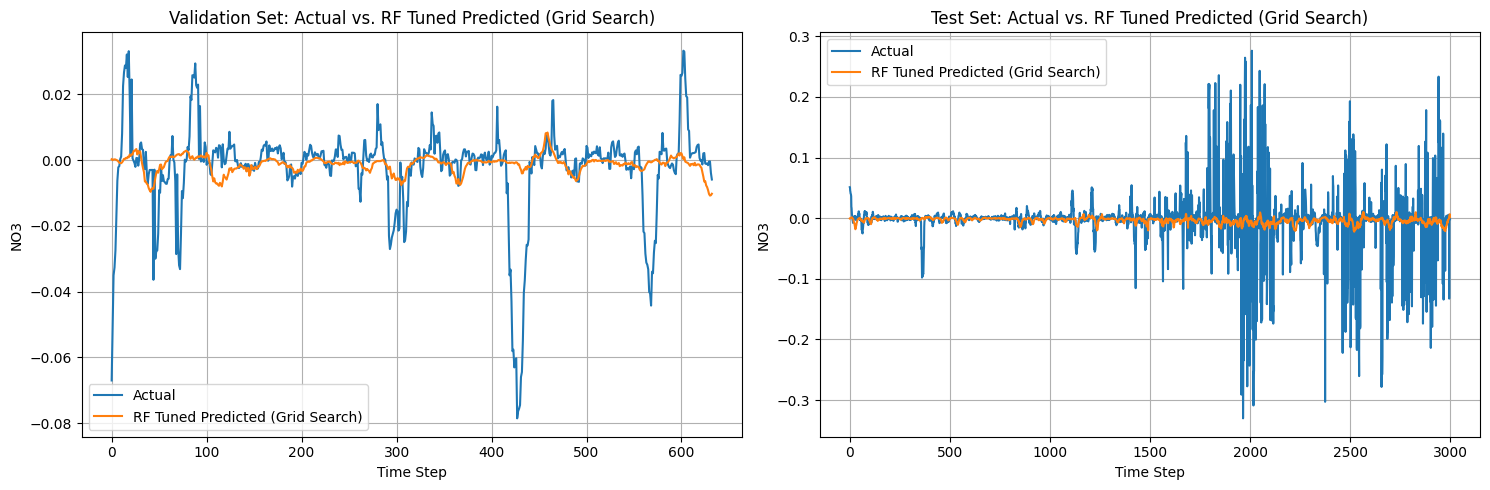


--- Tuned Model Using WOA ---
Tuned model is not better than the original model.
Original Model Validation MSE: 0.000195
Tuned Model Validation MSE: 0.000196

--- Tuned Residual Model Validation MSE Comparison ---


,Model,Validation MSE,Time Taken (s)
1,RF (Grid Search),0.000195,104.413399
0,RF (Random Search),0.000195,29.116078
2,RF (WOA),0.000195,28.588188


In [ ]:
y_residual_val_pred_rf_tuned = None
y_residual_test_pred_rf_tuned = None
residual_val_mse_rf_tuned = None

y_residual_val_pred_gs_tuned = None
y_residual_test_pred_gs_tuned = None
residual_val_mse_gs_tuned = None

y_residual_val_pred_woa_tuned = None
y_residual_test_pred_woa_tuned = None
residual_val_mse_woa_tuned = None

val_mse_comparison_data = []

print("--- Tuned Model Using Random Search ---")
y_residual_val_pred_rf_tuned, y_residual_test_pred_rf_tuned, residual_val_mse_rf_tuned = compare_models(
    best_residual_model_name, best_rf_residual_tuned_model, best_residual_model, best_rf_residual_tuned_val_mse, best_residual_val_mse,
    y_residual_val_windowed, y_residual_test_windowed, y_residual_val_pred, y_residual_test_pred, "Random Search"
)
val_mse_comparison_data.append({"Model": f"{best_residual_model_name} (Random Search)", "Validation MSE": residual_val_mse_rf_tuned, "Time Taken (s)": rf_residual_time})

print("\n--- Tuned Model Using Grid Search ---")
y_residual_val_pred_gs_tuned, y_residual_test_pred_gs_tuned, residual_val_mse_gs_tuned = compare_models(
    best_residual_model_name, best_gs_residual_tuned_model, best_residual_model, best_gs_residual_tuned_val_mse, best_residual_val_mse,
    y_residual_val_windowed, y_residual_test_windowed, y_residual_val_pred, y_residual_test_pred, "Grid Search"
)
val_mse_comparison_data.append({"Model": f"{best_residual_model_name} (Grid Search)", "Validation MSE": residual_val_mse_gs_tuned, "Time Taken (s)": gs_residual_time})

print("\n--- Tuned Model Using WOA ---")
y_residual_val_pred_woa_tuned, y_residual_test_pred_woa_tuned, residual_val_mse_woa_tuned = compare_models(
    best_residual_model_name, best_woa_residual_tuned_model, best_residual_model, best_woa_residual_tuned_val_mse, best_residual_val_mse,
    y_residual_val_windowed, y_residual_test_windowed, y_residual_val_pred, y_residual_test_pred, "WOA"
)
val_mse_comparison_data.append({"Model": f"{best_residual_model_name} (WOA)", "Validation MSE": residual_val_mse_woa_tuned, "Time Taken (s)": woa_residual_time})


comparison_df = pd.DataFrame(val_mse_comparison_data)
comparison_df = comparison_df.sort_values(by="Validation MSE")
print("\n--- Tuned Residual Model Validation MSE Comparison ---")
display(comparison_df)

# Hybrid Predictions


--- Hybrid Model Test Metrics Comparison (by Tuning Method Combination) ---


,Model Combination,Validation MSE,Test MSE,Test RMSE,Test R2,Test MAE,Tuning Time
0,GRU-Linear Regression-RF (Grid Search),0.000107,0.002304,0.047997,0.131503,0.030209,457.943387
1,GRU-Linear Regression-RF (Original),0.000106,0.002353,0.048503,0.113125,0.031275,0.000000
2,GRU-Linear Regression-RF (Random Search),0.000106,0.002353,0.048503,0.113125,0.031275,272.874064
3,GRU-Linear Regression-RF (WOA),0.000106,0.002353,0.048503,0.113125,0.031275,312.115218


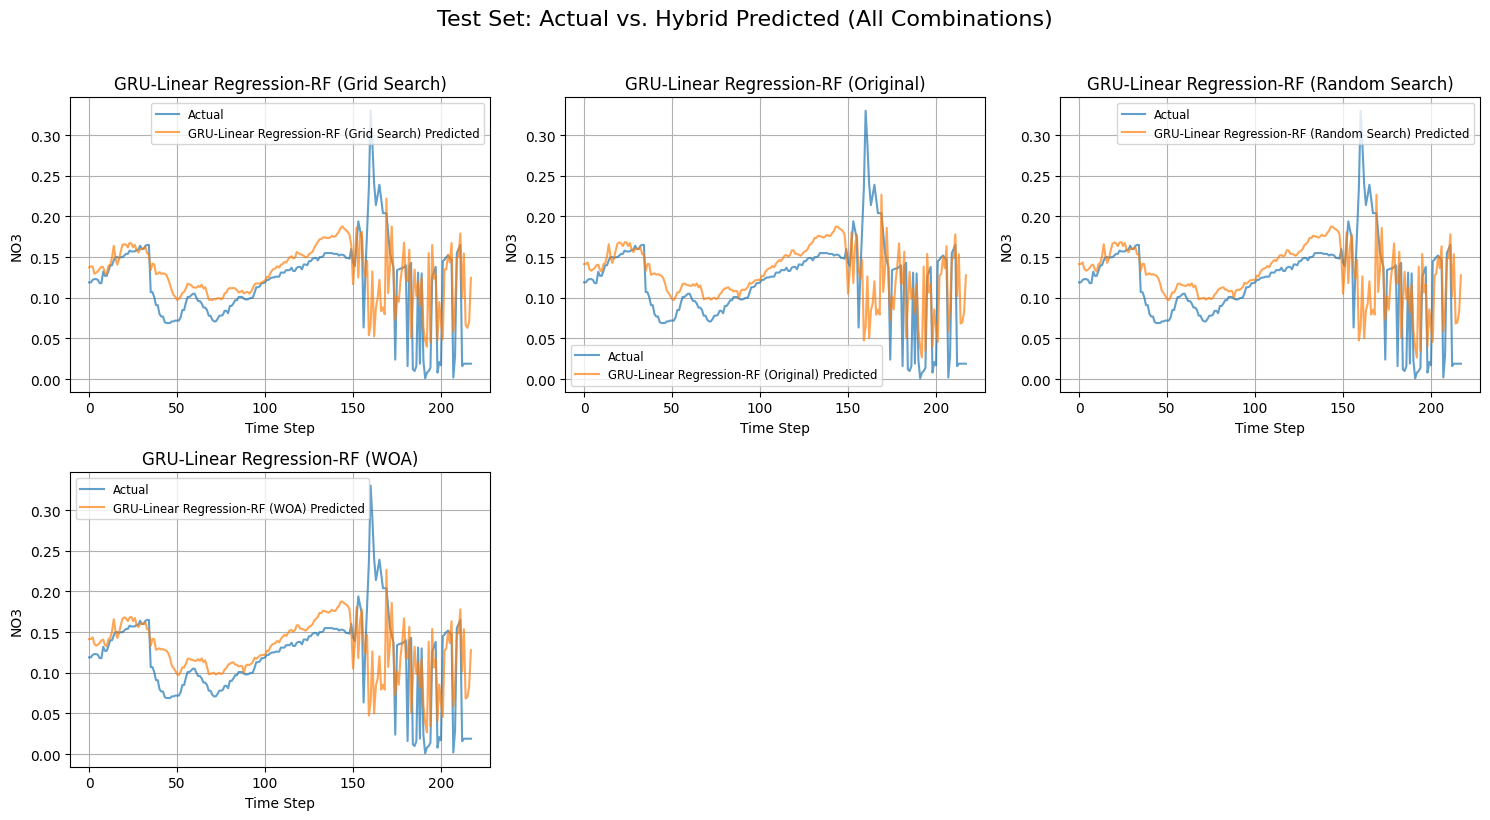

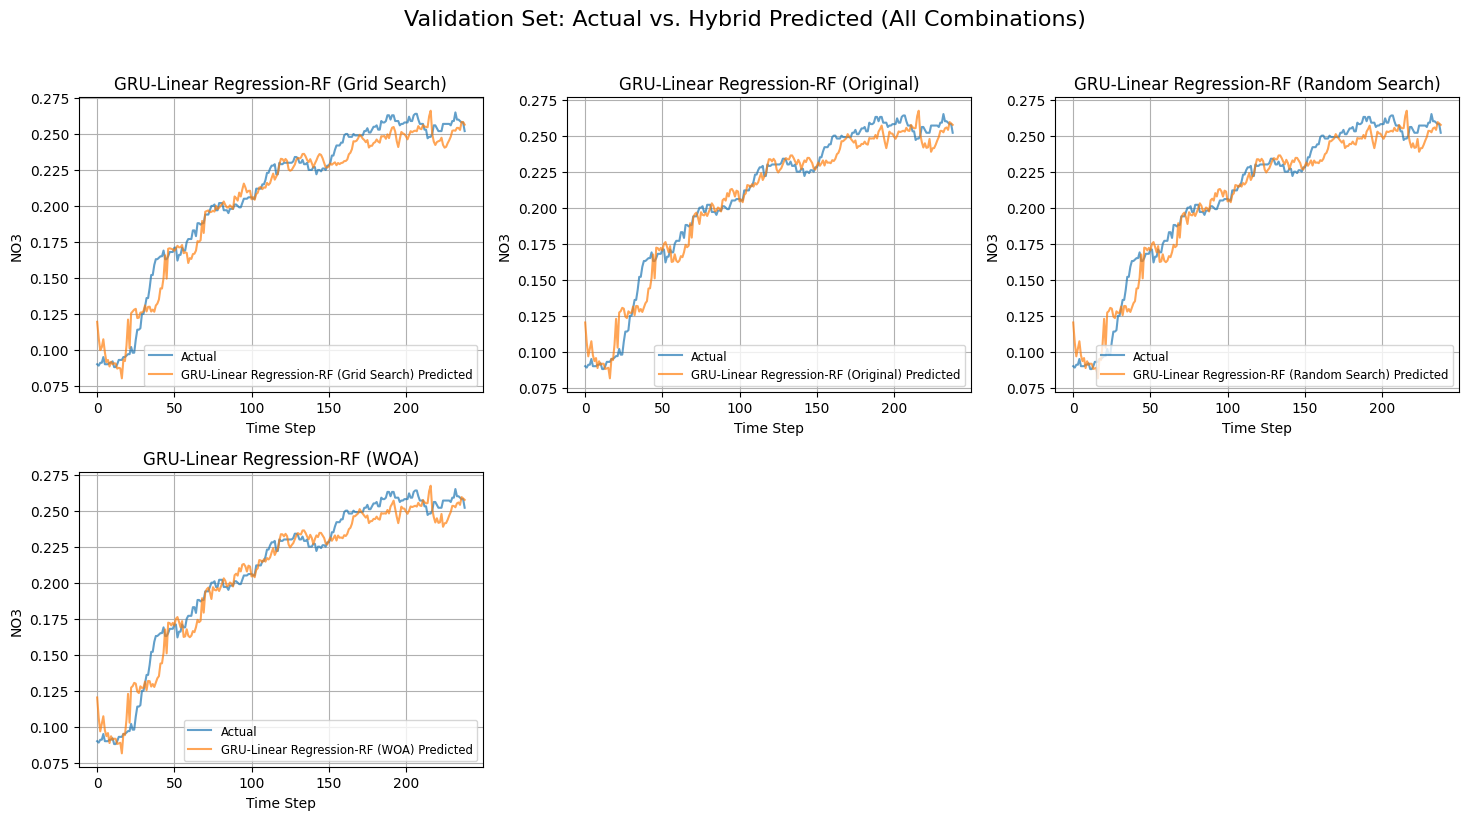

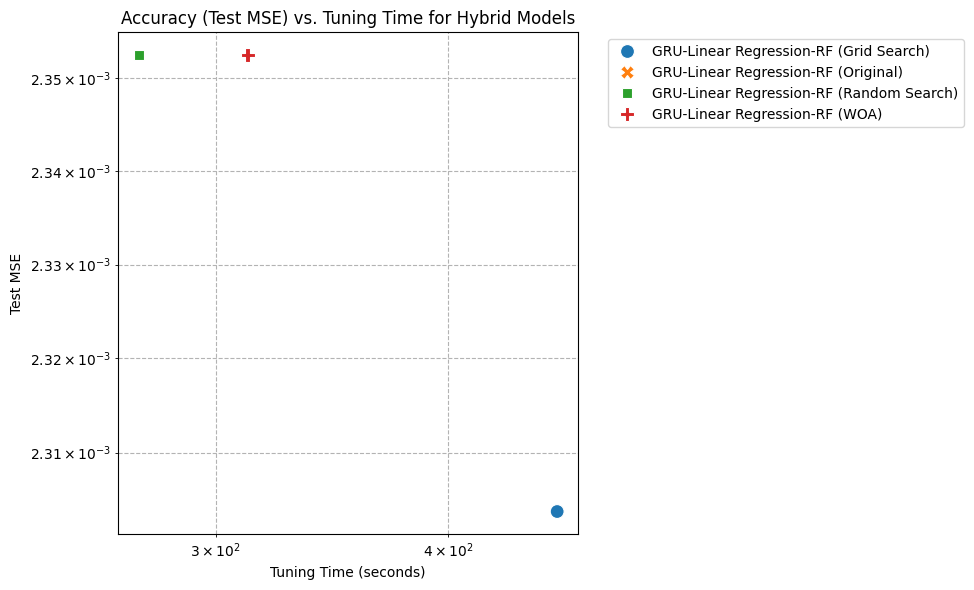

In [ ]:
tuning_methods = [
    {
        'name': 'Original',
        'trend_val': y_trend_val_pred,
        'trend_test': y_trend_test_pred,
        'season_val': y_season_val_pred,
        'season_test': y_season_test_pred,
        'residual_val': y_residual_val_pred,
        'residual_test': y_residual_test_pred,
        'tuning time': 0 # Assign 0 for original models, as they are not explicitly tuned in the same way
    },
    {
        'name': 'Random Search',
        'trend_val': y_trend_val_pred_rf_tuned,
        'trend_test': y_trend_test_pred_rf_tuned,
        'season_val': y_season_val_pred_rf_tuned,
        'season_test': y_season_test_pred_rf_tuned,
        'residual_val': y_residual_val_pred_rf_tuned,
        'residual_test': y_residual_test_pred_rf_tuned,
        'tuning time': rf_trend_time + rf_season_time + rf_residual_time
    },
    {
        'name': 'Grid Search',
        'trend_val': y_trend_val_pred_gs_tuned,
        'trend_test': y_trend_test_pred_gs_tuned,
        'season_val': y_season_val_pred_gs_tuned,
        'season_test': y_season_test_pred_gs_tuned,
        'residual_val': y_residual_val_pred_gs_tuned,
        'residual_test': y_residual_test_pred_gs_tuned,
        'tuning time': gs_trend_time + gs_season_time + gs_residual_time
    },
    {
        'name': 'WOA',
        'trend_val': y_trend_val_pred_woa_tuned,
        'trend_test': y_trend_test_pred_woa_tuned,
        'season_val': y_season_val_pred_woa_tuned,
        'season_test': y_season_test_pred_woa_tuned,
        'residual_val': y_residual_val_pred_woa_tuned,
        'residual_test': y_residual_test_pred_woa_tuned,
        'tuning time': woa_trend_time + woa_season_time + woa_residual_time
    }
]

hybrid_results = []

for method in tuning_methods:
    method_name = method['name']

    current_y_trend_val_pred = method['trend_val']
    current_y_season_val_pred = method['season_val']
    current_y_residual_val_pred = method['residual_val']

    current_y_trend_test_pred = method['trend_test']
    current_y_season_test_pred = method['season_test']
    current_y_residual_test_pred = method['residual_test']

    # Skip if any component prediction is None for this tuning method
    # This might happen if a tuning method was not run or failed for a specific component
    if any(p is None for p in [current_y_trend_val_pred, current_y_season_val_pred, current_y_residual_val_pred,
                               current_y_trend_test_pred, current_y_season_test_pred, current_y_residual_test_pred]):
        print(f"Skipping hybrid combination for tuning method: {method_name} due to None predictions.")
        continue

    # Ensure predictions are 2D for consistent DataFrame creation
    if current_y_trend_val_pred.ndim == 1: current_y_trend_val_pred = current_y_trend_val_pred.reshape(-1, 1)
    if current_y_season_val_pred.ndim == 1: current_y_season_val_pred = current_y_season_val_pred.reshape(-1, 1)
    if current_y_residual_val_pred.ndim == 1: current_y_residual_val_pred = current_y_residual_val_pred.reshape(-1, 1)

    if current_y_trend_test_pred.ndim == 1: current_y_trend_test_pred = current_y_trend_test_pred.reshape(-1, 1)
    if current_y_season_test_pred.ndim == 1: current_y_season_test_pred = current_y_season_test_pred.reshape(-1, 1)
    if current_y_residual_test_pred.ndim == 1: current_y_residual_test_pred = current_y_residual_test_pred.reshape(-1, 1)

    # Create DataFrames for validation predictions
    df_trend_val_pred = pd.DataFrame(
        current_y_trend_val_pred,
        index=t_trend_val,
        columns=[f"h{h+1}_trend" for h in range(current_y_trend_val_pred.shape[1])]
    )
    df_season_val_pred = pd.DataFrame(
        current_y_season_val_pred,
        index=t_season_val,
        columns=[f"h{h+1}_season" for h in range(current_y_season_val_pred.shape[1])]
    )
    df_resid_val_pred = pd.DataFrame(
        current_y_residual_val_pred,
        index=t_residual_val,
        columns=[f"h{h+1}_resid" for h in range(current_y_residual_val_pred.shape[1])]
    )

    # Join validation DataFrames
    df_val_all = (
        df_trend_val_pred
        .join(df_season_val_pred, how="inner")
        .join(df_resid_val_pred, how="inner")
    )
    y_hat_val_hybrid = (
        df_val_all.filter(like="_trend").values +
        df_val_all.filter(like="_season").values +
        df_val_all.filter(like="_resid").values
    )

    # Create DataFrames for test predictions
    df_trend_test_pred = pd.DataFrame(
        current_y_trend_test_pred,
        index=t_trend_test,
        columns=[f"h{h+1}_trend" for h in range(current_y_trend_test_pred.shape[1])]
    )
    df_season_test_pred = pd.DataFrame(
        current_y_season_test_pred,
        index=t_season_test,
        columns=[f"h{h+1}_season" for h in range(current_y_season_test_pred.shape[1])]
    )
    df_resid_test_pred = pd.DataFrame(
        current_y_residual_test_pred,
        index=t_residual_test,
        columns=[f"h{h+1}_resid" for h in range(current_y_residual_test_pred.shape[1])]
    )

    # Join test DataFrames
    df_test_all = (
        df_trend_test_pred
        .join(df_season_test_pred, how="inner")
        .join(df_resid_test_pred, how="inner")
    )
    y_hat_test_hybrid = (
        df_test_all.filter(like="_trend").values +
        df_test_all.filter(like="_season").values +
        df_test_all.filter(like="_resid").values
    )

    # Calculate target timestamps for evaluation
    target_val_eval_timestamps = df_val_all.index + pd.Timedelta(hours=forecast_horizon - 1)
    target_test_eval_timestamps = df_test_all.index + pd.Timedelta(hours=forecast_horizon - 1)

    # Get the actual trend, seasonal, and residual components at these target timestamps
    actual_trend_val_target    = trend_val.reindex(target_val_eval_timestamps)
    actual_season_val_target   = season_val.reindex(target_val_eval_timestamps)
    actual_residual_val_target = residual_val.reindex(target_val_eval_timestamps)

    actual_trend_test_target    = trend_test.reindex(target_test_eval_timestamps)
    actual_season_test_target   = season_test.reindex(target_test_eval_timestamps)
    actual_residual_test_target = residual_test.reindex(target_test_eval_timestamps)

    # Sum these aligned actual components to get the actual total NO3 at the forecast points
    y_actual_val_combined = (actual_trend_val_target + actual_season_val_target + actual_residual_val_target).dropna()
    y_actual_test_combined = (actual_trend_test_target + actual_season_test_target + actual_residual_test_target).dropna()

    # Align the hybrid predictions with these actual combined values
    y_hat_val_hybrid_aligned_to_actual = pd.Series(y_hat_val_hybrid.flatten(), index=target_val_eval_timestamps).reindex(y_actual_val_combined.index)
    y_hat_test_hybrid_aligned_to_actual = pd.Series(y_hat_test_hybrid.flatten(), index=target_test_eval_timestamps).reindex(y_actual_test_combined.index)

    # Calculate metrics for hybrid model
    combined_val_mse = mean_squared_error(y_actual_val_combined, y_hat_val_hybrid_aligned_to_actual)
    combined_test_mse, combined_test_rmse, combined_test_r2, combined_test_mae = calc_metrics(y_actual_test_combined, y_hat_test_hybrid_aligned_to_actual)

    hybrid_results.append({
        "Model Combination": f"{best_trend_model_name}-{best_season_model_name}-{best_residual_model_name} ({method_name})",
        "Validation MSE": combined_val_mse,
        "Test MSE": combined_test_mse,
        "Test RMSE": combined_test_rmse,
        "Test R2": combined_test_r2,
        "Test MAE": combined_test_mae,
        "y_hat_test_hybrid": y_hat_test_hybrid_aligned_to_actual,
        "y_hat_val_hybrid": y_hat_val_hybrid_aligned_to_actual,
        "Tuning Time": method['tuning time']
    })


hybrid_df = pd.DataFrame(hybrid_results)
hybrid_df = hybrid_df.sort_values(by="Test MSE").reset_index(drop=True)

print("\n--- Hybrid Model Test Metrics Comparison (by Tuning Method Combination) ---")
display(hybrid_df.drop(columns=['y_hat_test_hybrid', 'y_hat_val_hybrid']))

# Plotting all hybrid models for the Test Set
if not hybrid_df.empty:
    num_plots = len(hybrid_df)
    ncols = 3
    nrows = (num_plots + ncols - 1) // ncols

    plt.figure(figsize=(5 * ncols, 4 * nrows))
    plt.suptitle('Test Set: Actual vs. Hybrid Predicted (All Combinations)', y=1.02, fontsize=16)

    for i, row in hybrid_df.iterrows():
        model_name = row["Model Combination"]
        y_pred = row["y_hat_test_hybrid"]

        plt.subplot(nrows, ncols, i + 1)
        plt.plot(range(len(y_actual_test_combined)), y_actual_test_combined, label="Actual", alpha=0.7)
        plt.plot(range(len(y_pred)), y_pred, label=f"{model_name} Predicted", alpha=0.7)
        plt.title(f"{model_name}")
        plt.xlabel("Time Step")
        plt.ylabel("NO3")
        plt.legend(fontsize='small')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plotting all hybrid models for the Validation Set
if not hybrid_df.empty:
    num_plots = len(hybrid_df)
    ncols = 3
    nrows = (num_plots + ncols - 1) // ncols

    plt.figure(figsize=(5 * ncols, 4 * nrows))
    plt.suptitle('Validation Set: Actual vs. Hybrid Predicted (All Combinations)', y=1.02, fontsize=16)

    for i, row in hybrid_df.iterrows():
        model_name = row["Model Combination"]
        y_pred = row["y_hat_val_hybrid"]

        plt.subplot(nrows, ncols, i + 1)
        plt.plot(range(len(y_actual_val_combined)), y_actual_val_combined, label="Actual", alpha=0.7)
        plt.plot(range(len(y_pred)), y_pred, label=f"{model_name} Predicted", alpha=0.7)
        plt.title(f"{model_name}")
        plt.xlabel("Time Step")
        plt.ylabel("NO3")
        plt.legend(fontsize='small')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plotting Accuracy vs Time for Hybrid Models
if not hybrid_df.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=hybrid_df, x='Tuning Time', y='Test MSE', hue='Model Combination', s=100, style='Model Combination')
    plt.title('Accuracy (Test MSE) vs. Tuning Time for Hybrid Models')
    plt.xlabel('Tuning Time (seconds)')
    plt.ylabel('Test MSE')
    plt.xscale('log') # Use log scale for time if there's a wide range
    plt.yscale('log') # Use log scale for MSE if there's a wide range
    plt.grid(True, which="both", ls="--", c='0.7')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Train with Original target

## Data windowing

In [ ]:
original_look_back = 72

X_train_windowed, y_train_windowed, t_train = create_sequences(X_train_scaled, original_look_back, forecast_horizon)
X_val_windowed, y_val_windowed, t_val = create_sequences(X_val_scaled, original_look_back, forecast_horizon)
X_test_windowed, y_test_windowed, t_test = create_sequences(X_test_scaled, original_look_back, forecast_horizon)

X_train_windowed, y_train_windowed, t_train = drop_nan_windows(X_train_windowed, y_train_windowed, t_train)
X_val_windowed,   y_val_windowed, t_val   = drop_nan_windows(X_val_windowed, y_val_windowed, t_val)
X_test_windowed,  y_test_windowed, t_test  = drop_nan_windows(X_test_windowed, y_test_windowed, t_test)

print("Train:", X_train_windowed.shape)
print("Val:  ", X_val_windowed.shape)
print("Test: ", X_test_windowed.shape)

Train: (931, 72, 13)
Val:   (239, 72, 13)
Test:  (218, 72, 13)


In [ ]:
X_train_flattened = X_train_windowed.reshape(X_train_windowed.shape[0], -1)
X_val_flattened = X_val_windowed.reshape(X_val_windowed.shape[0], -1)
X_test_flattened = X_test_windowed.reshape(X_test_windowed.shape[0], -1)

print(f"Shape of X_train_flattened: {X_train_flattened.shape}")
print(f"Shape of X_val_flattened: {X_val_flattened.shape}")
print(f"Shape of X_test_flattened: {X_test_flattened.shape}")

Shape of X_train_flattened: (931, 936)
Shape of X_val_flattened: (239, 936)
Shape of X_test_flattened: (218, 936)


## Train & Test

### LSTM

In [ ]:
best_lstm_val_mse = float('inf')
best_lstm_model = None
best_lstm_history = None
best_lstm_iteration = -1

# Define the input shape for the LSTM model
lstm_input_shape = (X_train_windowed.shape[1], X_train_windowed.shape[2])

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_lstm(
        X_train_windowed, y_train_windowed,
        X_val_windowed, y_val_windowed,
        lstm_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_lstm_val_mse:
        best_lstm_val_mse = current_val_mse
        best_lstm_model = model
        best_lstm_history = history
        best_lstm_iteration = i + 1
        print(f"New best model found at iteration {best_lstm_iteration} with Validation MSE: {best_lstm_val_mse:.6f}")


--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.002838

--- Training Iteration 2/5 ---

--- Training Iteration 3/5 ---

--- Training Iteration 4/5 ---
New best model found at iteration 4 with Validation MSE: 0.001881

--- Training Iteration 5/5 ---
New best model found at iteration 5 with Validation MSE: 0.001821



--- Best Model (Iteration 5) ---
Best model weights saved to best_lstm_model_weights.weights.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
LSTM Test MSE: 0.006887
LSTM Test RMSE: 0.082989
LSTM Test R2: -1.596386
LSTM Test MAE: 0.048679


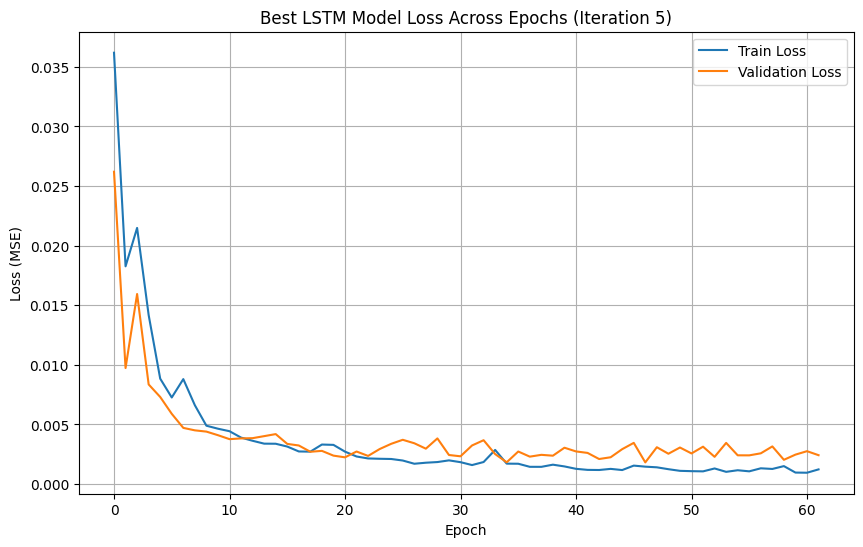

In [ ]:
print(f"\n--- Best Model (Iteration {best_lstm_iteration}) ---")

# Save the weights of the best model
best_lstm_model_weights_path = 'best_lstm_model_weights.weights.h5'
best_lstm_model.save_weights(best_lstm_model_weights_path)
print(f"Best model weights saved to {best_lstm_model_weights_path}")

y_lstm_test_pred = best_lstm_model.predict(X_test_windowed)
test_lstm_mse, test_lstm_rmse, test_lstm_r2, test_lstm_mae = calc_metrics(y_test_windowed, y_lstm_test_pred)
print(f"LSTM Test MSE: {test_lstm_mse:.6f}")
print(f"LSTM Test RMSE: {test_lstm_rmse:.6f}")
print(f"LSTM Test R2: {test_lstm_r2:.6f}")
print(f"LSTM Test MAE: {test_lstm_mae:.6f}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_lstm_history.history['loss'], label='Train Loss')
plt.plot(best_lstm_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best LSTM Model Loss Across Epochs (Iteration {best_lstm_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### GRU

In [ ]:
best_gru_val_mse = float('inf')
best_gru_model = None
best_gru_history = None
best_gru_iteration = -1

# Define the input shape for the GRU model
gru_input_shape = (X_train_windowed.shape[1], X_train_windowed.shape[2])

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_gru(
        X_train_windowed, y_train_windowed,
        X_val_windowed, y_val_windowed,
        gru_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_gru_val_mse:
        best_gru_val_mse = current_val_mse
        best_gru_model = model
        best_gru_history = history
        best_gru_iteration = i + 1
        print(f"New best model found at iteration {best_gru_iteration} with Validation MSE: {best_gru_val_mse:.6f}")


--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.002534

--- Training Iteration 2/5 ---
New best model found at iteration 2 with Validation MSE: 0.001168

--- Training Iteration 3/5 ---

--- Training Iteration 4/5 ---

--- Training Iteration 5/5 ---



--- Best Model (Iteration 2) ---
Best model weights saved to best_gru_model_weights.weights.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
GRU Test MSE: 0.022651
GRU Test RMSE: 0.150501
GRU Test R2: -7.539068
GRU Test MAE: 0.117137


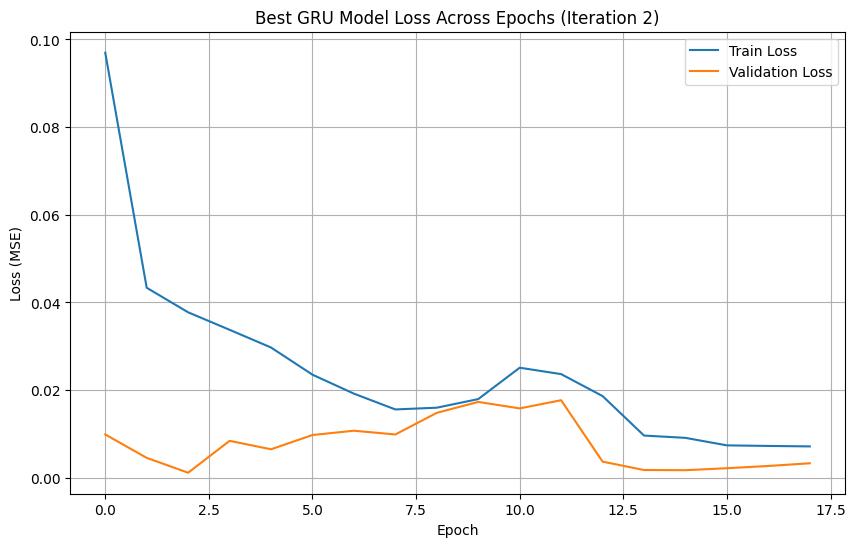

In [ ]:
print(f"\n--- Best Model (Iteration {best_gru_iteration}) ---")

# Save the weights of the best model
best_gru_model_weights_path = 'best_gru_model_weights.weights.h5'
best_gru_model.save_weights(best_gru_model_weights_path)
print(f"Best model weights saved to {best_gru_model_weights_path}")

y_gru_test_pred = best_gru_model.predict(X_test_windowed)
test_gru_mse, test_gru_rmse, test_gru_r2, test_gru_mae = calc_metrics(y_test_windowed, y_gru_test_pred)
print(f"GRU Test MSE: {test_gru_mse:.6f}")
print(f"GRU Test RMSE: {test_gru_rmse:.6f}")
print(f"GRU Test R2: {test_gru_r2:.6f}")
print(f"GRU Test MAE: {test_gru_mae:.6f}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_gru_history.history['loss'], label='Train Loss')
plt.plot(best_gru_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best GRU Model Loss Across Epochs (Iteration {best_gru_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### NARNET

In [ ]:
X_train_narnet = X_train_windowed[:, :, X_train_scaled.columns.get_loc(target_col)]
X_val_narnet = X_val_windowed[:, :, X_val_scaled.columns.get_loc(target_col)]
X_test_narnet = X_test_windowed[:, :, X_test_scaled.columns.get_loc(target_col)]

In [ ]:
best_narnet_val_mse = float('inf')
best_narnet_model = None
best_narnet_history = None
best_narnet_iteration = -1

# Define the input shape for the GRU model
narnet_input_shape = (original_look_back,)

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_narnet(
        X_train_narnet, y_train_windowed,
        X_val_narnet, y_val_windowed,
        narnet_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_narnet_val_mse:
        best_narnet_val_mse = current_val_mse
        best_narnet_model = model
        best_narnet_history = history
        best_narnet_iteration = i + 1
        print(f"New best model found at iteration {best_narnet_iteration} with Validation MSE: {best_narnet_val_mse:.6f}")


--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.001470

--- Training Iteration 2/5 ---
New best model found at iteration 2 with Validation MSE: 0.001200

--- Training Iteration 3/5 ---
New best model found at iteration 3 with Validation MSE: 0.001050

--- Training Iteration 4/5 ---

--- Training Iteration 5/5 ---
New best model found at iteration 5 with Validation MSE: 0.000586



--- Best Model (Iteration 5) ---
Best model weights saved to best_narnet_model_weights.weights.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
NARNET Test MSE: 0.003204
NARNET Test RMSE: 0.056605
NARNET Test R2: -0.207942
NARNET Test MAE: 0.037989


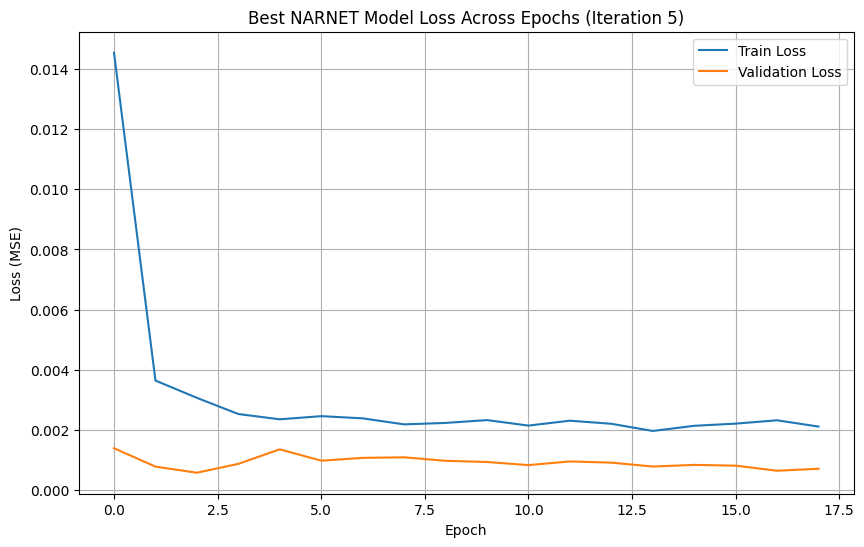

In [ ]:
print(f"\n--- Best Model (Iteration {best_narnet_iteration}) ---")

# Save the weights of the best model
best_narnet_model_weights_path = 'best_narnet_model_weights.weights.h5'
best_narnet_model.save_weights(best_narnet_model_weights_path)
print(f"Best model weights saved to {best_narnet_model_weights_path}")

y_narnet_test_pred = best_narnet_model.predict(X_test_narnet)
test_narnet_mse, test_narnet_rmse, test_narnet_r2, test_narnet_mae = calc_metrics(y_test_windowed, y_narnet_test_pred)
print(f"NARNET Test MSE: {test_narnet_mse:.6f}")
print(f"NARNET Test RMSE: {test_narnet_rmse:.6f}")
print(f"NARNET Test R2: {test_narnet_r2:.6f}")
print(f"NARNET Test MAE: {test_narnet_mae:.6f}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_narnet_history.history['loss'], label='Train Loss')
plt.plot(best_narnet_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best NARNET Model Loss Across Epochs (Iteration {best_narnet_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Linear Regression

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train_flattened, y_train_windowed)
print("Linear Regression model trained.")

y_linear_val_pred = linear_model.predict(X_val_flattened)

val_mse_linear = mean_squared_error(y_val_windowed, y_linear_val_pred)
print(f"\nLinear Regression Validation MSE: {val_mse_linear:.6f}")

y_linear_test_pred = linear_model.predict(X_test_flattened)
test_linear_mse, test_linear_rmse, test_linear_r2, test_linear_mae = calc_metrics(y_test_windowed, y_linear_test_pred)
print(f"Linear Regression Test MSE: {test_linear_mse:.6f}")
print(f"Linear Regression Test RMSE: {test_linear_rmse:.6f}")
print(f"Linear Regression Test R2: {test_linear_r2:.6f}")
print(f"Linear Regression Test MAE: {test_linear_mae:.6f}")

Linear Regression model trained.

Linear Regression Validation MSE: 0.008425
Linear Regression Test MSE: 0.033372
Linear Regression Test RMSE: 0.182679
Linear Regression Test R2: -11.580889
Linear Regression Test MAE: 0.122232


### MLP

In [ ]:
best_mlp_val_mse = float('inf')
best_mlp_model = None
best_mlp_history = None
best_mlp_iteration = -1

# Define the input shape for the MLP model
mlp_input_shape = (X_train_flattened.shape[1],)

for i in range(num_iterations):
    print(f"\n--- Training Iteration {i+1}/{num_iterations} ---")
    model, history = train_evaluate_mlp(
        X_train_flattened, y_train_windowed,
        X_val_flattened, y_val_windowed,
        mlp_input_shape
    )

    # Get the minimum validation loss from the current history
    current_val_mse = min(history.history['val_loss'])

    if current_val_mse < best_mlp_val_mse:
        best_mlp_val_mse = current_val_mse
        best_mlp_model = model
        best_mlp_history = history
        best_mlp_iteration = i + 1
        print(f"New best model found at iteration {best_mlp_iteration} with Validation MSE: {best_mlp_val_mse:.6f}")


--- Training Iteration 1/5 ---
New best model found at iteration 1 with Validation MSE: 0.003166

--- Training Iteration 2/5 ---
New best model found at iteration 2 with Validation MSE: 0.002480

--- Training Iteration 3/5 ---

--- Training Iteration 4/5 ---

--- Training Iteration 5/5 ---



--- Best Model (Iteration 2) ---
Best model weights saved to best_mlp_model_weights.weights.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
MLP Test MSE: 0.008981
MLP Test RMSE: 0.094770
MLP Test R2: -2.385893
MLP Test MAE: 0.069676


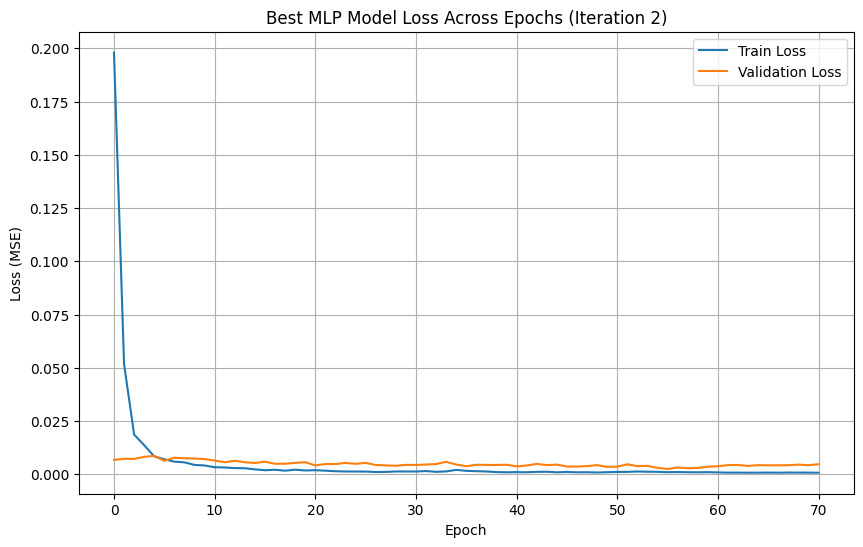

In [ ]:
print(f"\n--- Best Model (Iteration {best_mlp_iteration}) ---")

# Save the weights of the best model
best_mlp_model_weights_path = 'best_mlp_model_weights.weights.h5'
best_mlp_model.save_weights(best_mlp_model_weights_path)
print(f"Best model weights saved to {best_mlp_model_weights_path}")

y_mlp_test_pred = best_mlp_model.predict(X_test_flattened)
test_mlp_mse, test_mlp_rmse, test_mlp_r2, test_mlp_mae = calc_metrics(y_test_windowed, y_mlp_test_pred)
print(f"MLP Test MSE: {test_mlp_mse:.6f}")
print(f"MLP Test RMSE: {test_mlp_rmse:.6f}")
print(f"MLP Test R2: {test_mlp_r2:.6f}")
print(f"MLP Test MAE: {test_mlp_mae:.6f}")

# Plot training and validation loss for the best model
plt.figure(figsize=(10, 6))
plt.plot(best_mlp_history.history['loss'], label='Train Loss')
plt.plot(best_mlp_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best MLP Model Loss Across Epochs (Iteration {best_mlp_iteration})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### XGBoost

In [ ]:
# Instantiate an XGBoost Regressor model
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.6,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

# Train the model
xgb_model.fit(X_train_flattened, y_train_windowed)
print("XGBoost Regressor model trained.")

# Make predictions on the test set
y_xgb_val_pred = xgb_model.predict(X_val_flattened)
# Calculate Mean Squared Error
val_mse_xgb = mean_squared_error(y_val_windowed, y_xgb_val_pred)
print(f"\nXGBoost Regressor Validation MSE: {val_mse_xgb:.6f}")

y_xgb_test_pred = xgb_model.predict(X_test_flattened)
test_xgb_mse, test_xgb_rmse, test_xgb_r2, test_xgb_mae = calc_metrics(y_test_windowed, y_xgb_test_pred)
print(f"XGBoost Regressor Test MSE: {test_xgb_mse:.6f}")
print(f"XGBoost Regressor Test RMSE: {test_xgb_rmse:.6f}")
print(f"XGBoost Regressor Test R2: {test_xgb_r2:.6f}")
print(f"XGBoost Regressor Test MAE: {test_xgb_mae:.6f}")

XGBoost Regressor model trained.

XGBoost Regressor Validation MSE: 0.000329
XGBoost Regressor Test MSE: 0.003561
XGBoost Regressor Test RMSE: 0.059677
XGBoost Regressor Test R2: -0.342619
XGBoost Regressor Test MAE: 0.040629


### RF

In [ ]:
# Instantiate a RandomForestRegressor model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

# Train the model
rf_model.fit(X_train_flattened, y_train_windowed)
print("RandomForestRegressor model trained.")

# Make predictions on the test set
y_rf_val_pred = rf_model.predict(X_val_flattened)

# Calculate Mean Squared Error
val_mse_rf = mean_squared_error(y_val_windowed, y_rf_val_pred)
print(f"\nRandomForestRegressor Validation MSE: {val_mse_rf:.6f}")

y_rf_test_pred = rf_model.predict(X_test_flattened)
test_rf_mse, test_rf_rmse, test_rf_r2, test_rf_mae = calc_metrics(y_test_windowed, y_rf_test_pred)
print(f"RandomForestRegressor Test MSE: {test_rf_mse:.6f}")
print(f"RandomForestRegressor Test RMSE: {test_rf_rmse:.6f}")
print(f"RandomForestRegressor Test R2: {test_rf_r2:.6f}")
print(f"RandomForestRegressor Test MAE: {test_rf_mae:.6f}")

RandomForestRegressor model trained.

RandomForestRegressor Validation MSE: 0.000366
RandomForestRegressor Test MSE: 0.005437
RandomForestRegressor Test RMSE: 0.073738
RandomForestRegressor Test R2: -1.049821
RandomForestRegressor Test MAE: 0.057252


### SVR

In [ ]:
# Instantiate an SVR model
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.05)
print("SVR model instantiated.")

# Train the model
svr_model.fit(X_train_flattened, y_train_windowed)
print("SVR model trained.")

# Make predictions on the test set
y_svr_val_pred = svr_model.predict(X_val_flattened)
print("Predictions generated for the test set.")

# Calculate Mean Squared Error
val_mse_svr = mean_squared_error(y_val_windowed, y_svr_val_pred)
print(f"\nSVR Validation MSE: {val_mse_svr:.6f}")

y_svr_test_pred = svr_model.predict(X_test_flattened)
test_svr_mse, test_svr_rmse, test_svr_r2, test_svr_mae = calc_metrics(y_test_windowed, y_svr_test_pred)
print(f"SVR Test MSE: {test_svr_mse:.6f}")
print(f"SVR Test RMSE: {test_svr_rmse:.6f}")
print(f"SVR Test R2: {test_svr_r2:.6f}")
print(f"SVR Test MAE: {test_svr_mae:.6f}")

SVR model instantiated.
SVR model trained.
Predictions generated for the test set.

SVR Validation MSE: 0.001693
SVR Test MSE: 0.007433
SVR Test RMSE: 0.086213
SVR Test R2: -1.802072
SVR Test MAE: 0.071937


## Baseline Validation Performance

In [ ]:
baseline_results = [
    {"Model": "LSTM", "Validation MSE": best_lstm_val_mse},
    {"Model": "GRU", "Validation MSE": best_gru_val_mse},
    {"Model": "NARNET", "Validation MSE": best_narnet_val_mse},
    {"Model": "Linear Regression", "Validation MSE": val_mse_linear},
    {"Model": "MLP", "Validation MSE": best_mlp_val_mse},
    {"Model": "XGBoost", "Validation MSE": val_mse_xgb},
    {"Model": "SVR", "Validation MSE": val_mse_svr},
]

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values(by="Validation MSE").reset_index(drop=True)

print("--- Baseline Model Validation MSE Comparison ---")
display(baseline_df)

## *Predictions*


--- All Model Test MSE Comparison (including all hybrid combinations) ---


,Model,Test MSE,Test RMSE,Test R2,Test MAE,Improvement over Best Hybrid (%)
0,GRU-Linear Regression-RF (Grid Search),0.002304,0.047997,0.131503,0.030209,-0.00
1,GRU-Linear Regression-RF (Original),0.002353,0.048503,0.113125,0.031275,2.12
2,GRU-Linear Regression-RF (Random Search),0.002353,0.048503,0.113125,0.031275,2.12
3,GRU-Linear Regression-RF (WOA),0.002353,0.048503,0.113125,0.031275,2.12
11,NARNET,0.003204,0.056605,-0.207942,0.037989,39.08
6,XGBoost,0.003561,0.059677,-0.342619,0.040629,54.59
7,Random Forest,0.005437,0.073738,-1.049821,0.057252,136.02
9,LSTM,0.006887,0.082989,-1.596386,0.048679,198.95
8,SVR,0.007433,0.086213,-1.802072,0.071937,222.63
5,MLP,0.008981,0.094770,-2.385893,0.069676,289.86


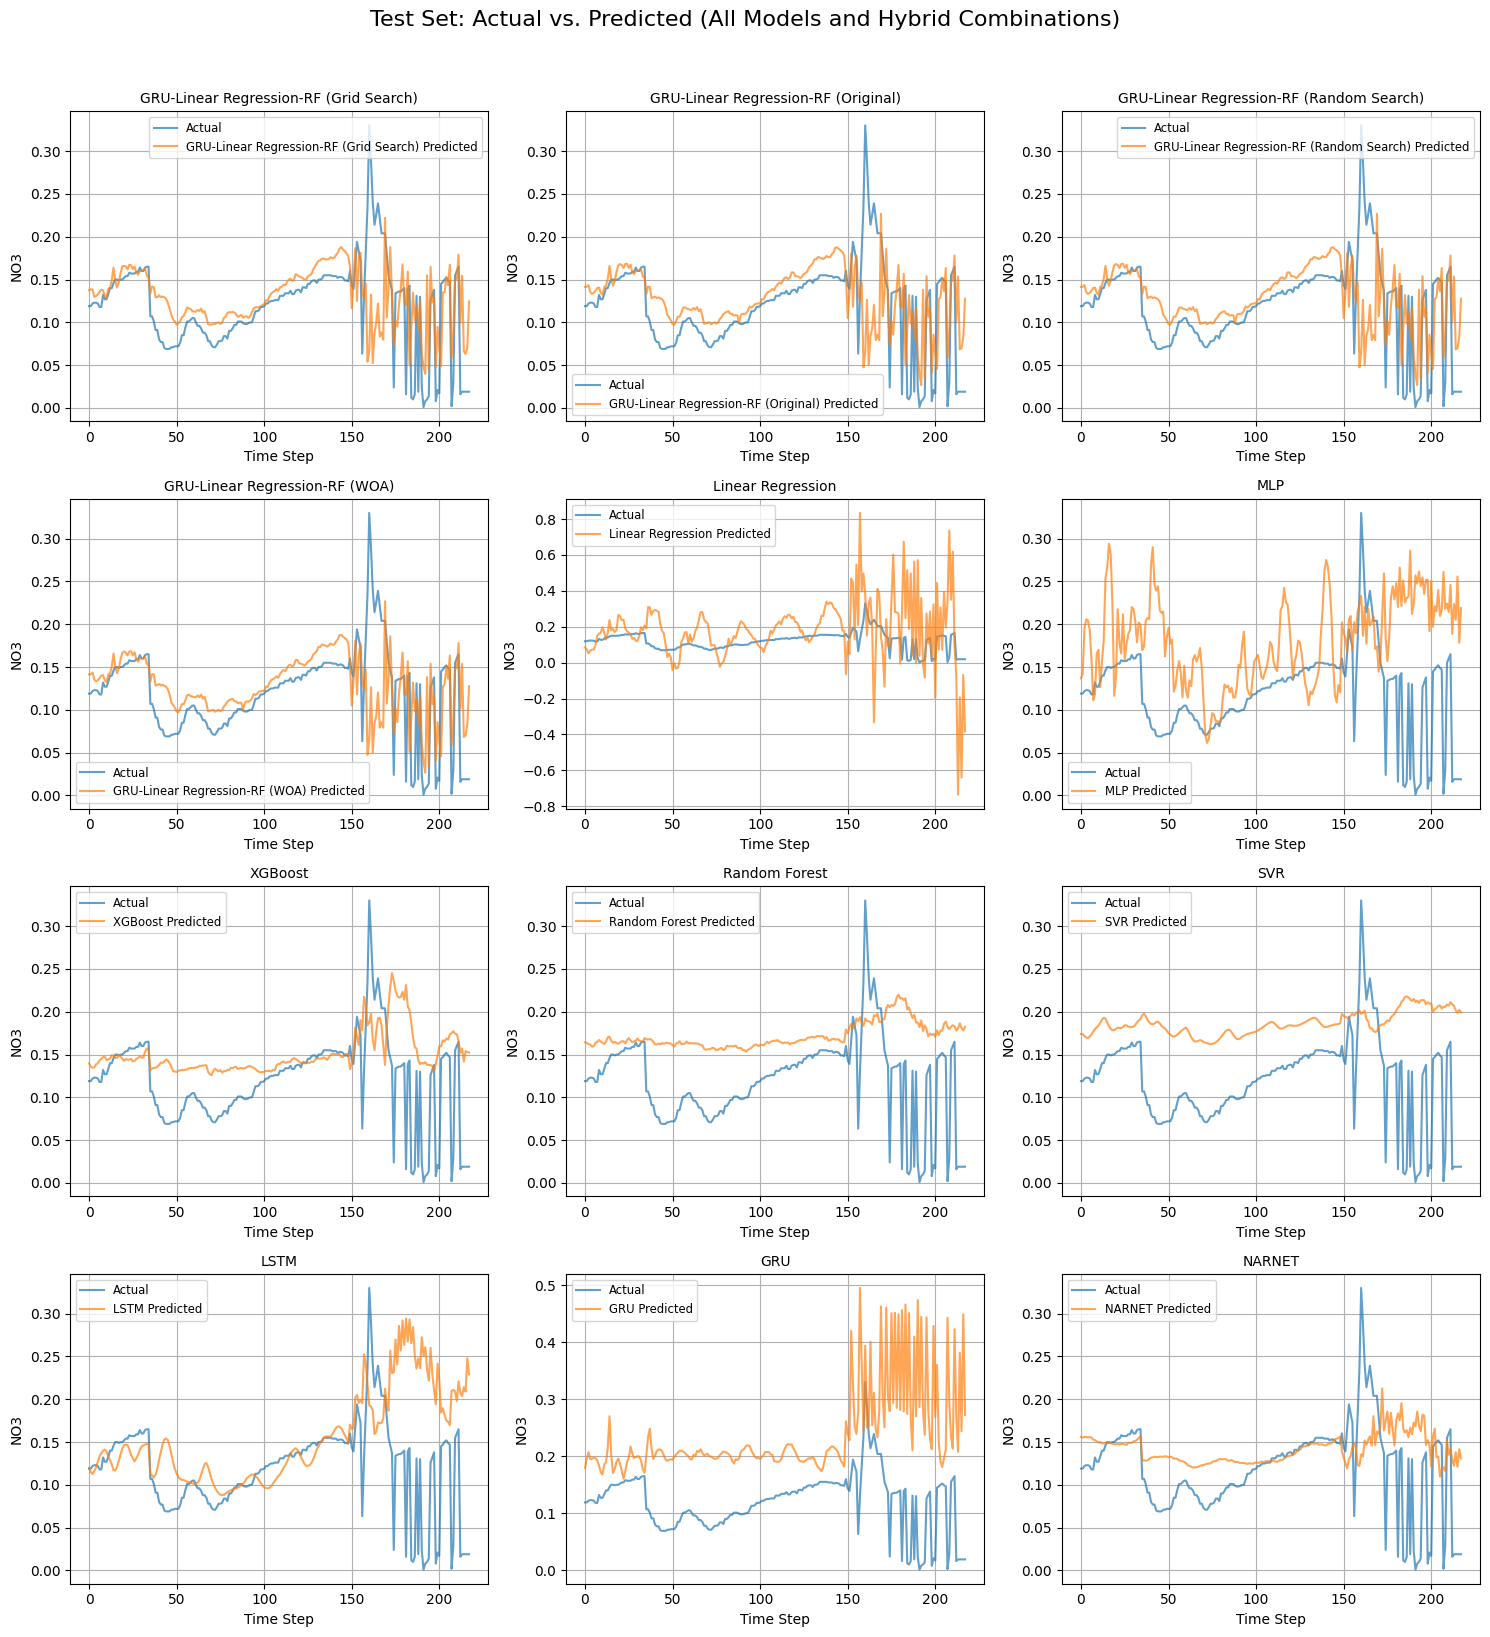

In [ ]:
best_hybrid_row_overall = hybrid_df.iloc[0]
best_hybrid_model_name_overall = best_hybrid_row_overall["Model Combination"]
best_hybrid_test_mse_overall = best_hybrid_row_overall["Test MSE"]

models_to_plot = []

# Add all hybrid models to the list
for _, row in hybrid_df.iterrows():
    models_to_plot.append((
        f"{row["Model Combination"]}",
        row["y_hat_test_hybrid"],
        row["Test MSE"],
        row["Test RMSE"],
        row["Test R2"],
        row["Test MAE"]
    ))

# Add individual models to the list
models_to_plot.extend([
    ("Linear Regression", y_linear_test_pred, test_linear_mse, test_linear_rmse, test_linear_r2, test_linear_mae),
    ("MLP", y_mlp_test_pred, test_mlp_mse, test_mlp_rmse, test_mlp_r2, test_mlp_mae),
    ("XGBoost", y_xgb_test_pred, test_xgb_mse, test_xgb_rmse, test_xgb_r2, test_xgb_mae),
    ("Random Forest", y_rf_test_pred, test_rf_mse, test_rf_rmse, test_rf_r2, test_rf_mae),
    ("SVR", y_svr_test_pred, test_svr_mse, test_svr_rmse, test_svr_r2, test_svr_mae),
    ("LSTM", y_lstm_test_pred, test_lstm_mse, test_lstm_rmse, test_lstm_r2, test_lstm_mae),
    ("GRU", y_gru_test_pred, test_gru_mse, test_gru_rmse, test_gru_r2, test_gru_mae),
    ("NARNET", y_narnet_test_pred, test_narnet_mse, test_narnet_rmse, test_narnet_r2, test_narnet_mae)
])


mse_data = {
    "Model": [item[0] for item in models_to_plot],
    "Test MSE": [item[2] for item in models_to_plot],
    "Test RMSE": [item[3] for item in models_to_plot],
    "Test R2": [item[4] for item in models_to_plot],
    "Test MAE": [item[5] for item in models_to_plot]
}
mse_df = pd.DataFrame(mse_data)

# Calculate improvement over the single best hybrid model (overall)
if not mse_df.empty:
    mse_df['Improvement over Best Hybrid (%)'] = -((best_hybrid_test_mse_overall - mse_df['Test MSE']) / best_hybrid_test_mse_overall) * 100
    mse_df['Improvement over Best Hybrid (%)'] = mse_df['Improvement over Best Hybrid (%)'].round(2)
    mse_df.loc[mse_df['Model'] == f"Hybrid ({best_hybrid_model_name_overall})", 'Improvement over Best Hybrid (%)'] = 0.0 # Best hybrid is 0% improvement over itself

mse_df = mse_df.sort_values(by="Test MSE")

print("\n--- All Model Test MSE Comparison (including all hybrid combinations) ---")
display(mse_df)


num_plots = len(models_to_plot)
ncols = 3
nrows = (num_plots + ncols - 1) // ncols

plt.figure(figsize=(5 * ncols, 4 * nrows))
plt.suptitle('Test Set: Actual vs. Predicted (All Models and Hybrid Combinations)', y=1.02, fontsize=16)

for i, (model_name, y_pred, _, _, _, _) in enumerate(models_to_plot):
    # Flatten predictions if they are 2D (e.g., Keras models output (samples, 1))
    if isinstance(y_pred, np.ndarray) and y_pred.ndim > 1:
        y_pred = y_pred.flatten()
    # Convert pandas Series to numpy array for plotting if it's the hybrid model
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.values

    plt.subplot(nrows, ncols, i + 1)
    plt.plot(range(len(y_test_windowed)), y_test_windowed, label="Actual", alpha=0.7)
    plt.plot(range(len(y_pred)), y_pred, label=f"{model_name} Predicted", alpha=0.7)
    plt.title(f"{model_name}", fontsize=10)
    plt.xlabel("Time Step")
    plt.ylabel("NO3")
    plt.legend(fontsize='small')
    plt.grid(True)

plt.tight_layout()
plt.show()


--- Improvement of Baseline Models Over Hybrid Models (Test MSE) ---


,Baseline Model,Hybrid Model,Improvement (%)
24,GRU,GRU-Linear Regression-RF (Grid Search),883.200208
25,GRU,GRU-Linear Regression-RF (Original),862.826241
26,GRU,GRU-Linear Regression-RF (Random Search),862.826241
27,GRU,GRU-Linear Regression-RF (WOA),862.826241
20,LSTM,GRU-Linear Regression-RF (Grid Search),198.951502
21,LSTM,GRU-Linear Regression-RF (Original),192.756601
22,LSTM,GRU-Linear Regression-RF (Random Search),192.756601
23,LSTM,GRU-Linear Regression-RF (WOA),192.756601
0,Linear Regression,GRU-Linear Regression-RF (Grid Search),1348.581078
1,Linear Regression,GRU-Linear Regression-RF (Original),1318.563444


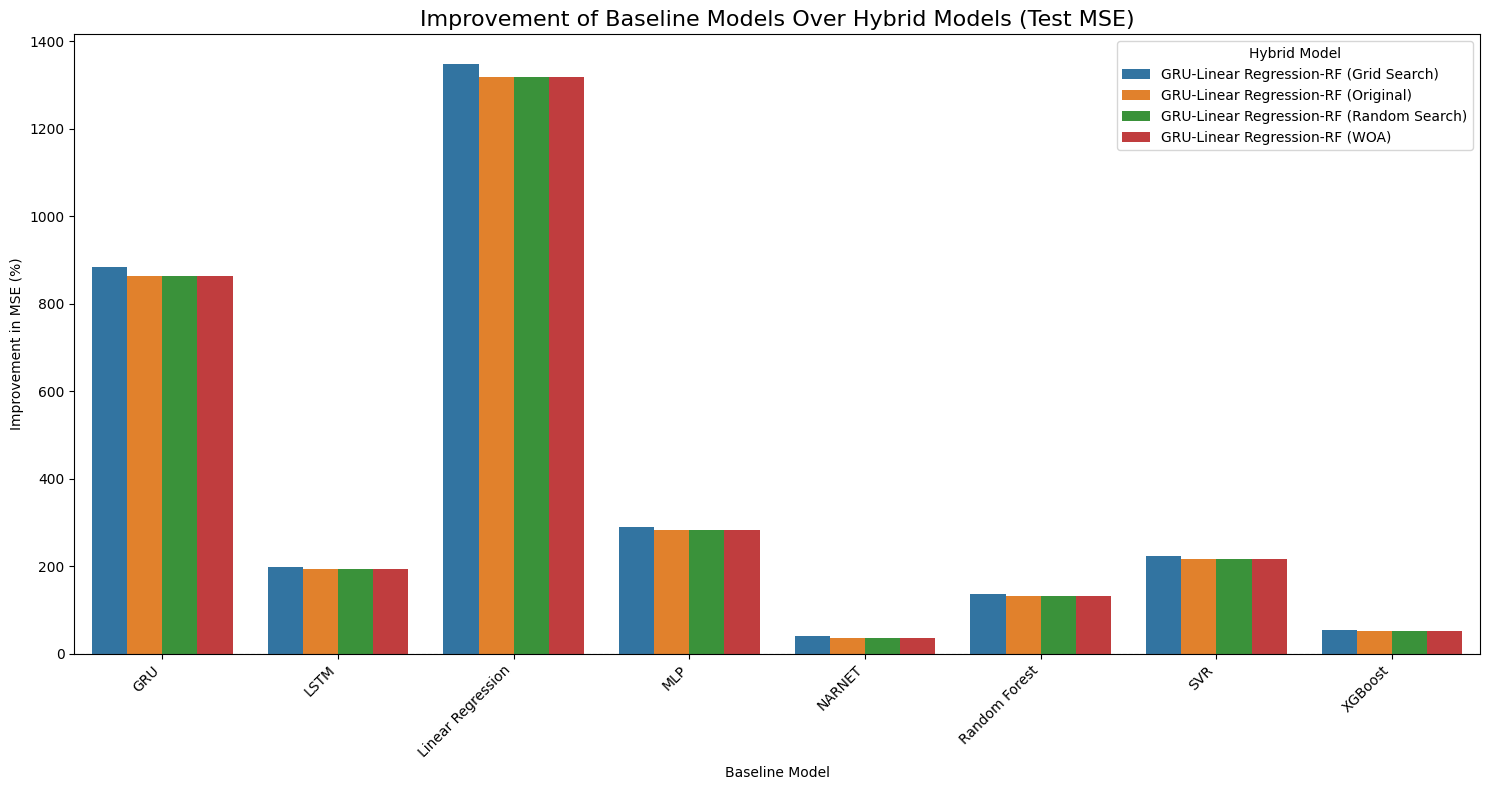

In [ ]:
mse_df = pd.DataFrame(mse_data)

# --- New comparison logic starts here ---

# Separate hybrid and baseline models using the actual hybrid model names from hybrid_df
hybrid_model_names = hybrid_df['Model Combination'].tolist()
hybrid_performance_df = mse_df[mse_df['Model'].isin(hybrid_model_names)].copy()
baseline_performance_df = mse_df[~mse_df['Model'].isin(hybrid_model_names)].copy()

comparison_results = []

for _, baseline_row in baseline_performance_df.iterrows():
    baseline_model_name = baseline_row['Model']
    baseline_mse = baseline_row['Test MSE']

    for _, hybrid_row in hybrid_performance_df.iterrows():
        hybrid_model_name = hybrid_row['Model']
        hybrid_mse = hybrid_row['Test MSE']

        # Calculate improvement: positive if baseline is better (lower MSE) than hybrid
        # Formula: ((hybrid_mse - baseline_mse) / hybrid_mse) * 100
        # If baseline MSE is 0.001 and hybrid MSE is 0.002, improvement = ((0.002 - 0.001) / 0.002) * 100 = 50%
        # If baseline MSE is 0.002 and hybrid MSE is 0.001, improvement = ((0.001 - 0.002) / 0.001) * 100 = -100%
        if hybrid_mse != 0:
            improvement = -((hybrid_mse - baseline_mse) / hybrid_mse) * 100
        else:
            improvement = np.nan # Avoid division by zero

        comparison_results.append({
            'Baseline Model': baseline_model_name,
            'Hybrid Model': hybrid_model_name,
            'Improvement (%)': improvement
        })

comparison_df_new = pd.DataFrame(comparison_results)
comparison_df_new = comparison_df_new.sort_values(by=["Baseline Model", "Hybrid Model"])

print("\n--- Improvement of Baseline Models Over Hybrid Models (Test MSE) ---")
display(comparison_df_new)

# Generate bar chart
plt.figure(figsize=(15, 8))
sns.barplot(data=comparison_df_new, x='Baseline Model', y='Improvement (%)', hue='Hybrid Model')
plt.title('Improvement of Baseline Models Over Hybrid Models (Test MSE)', fontsize=16)
plt.ylabel('Improvement in MSE (%)')
plt.xlabel('Baseline Model')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0% improvement
plt.tight_layout()
plt.show()

# --- Original comparison (if still desired, can be re-added or modified) ---
# The following lines are commented out as per the request to replace the original comparison.
# If you still want the overall best hybrid comparison, these can be uncommented or adjusted.
# if not mse_df.empty:
#     mse_df['Improvement over Best Hybrid (%)'] = ((best_hybrid_test_mse_overall - mse_df['Test MSE']) / best_hybrid_test_mse_overall) * 100
#     mse_df['Improvement over Best Hybrid (%)'] = mse_df['Improvement over Best Hybrid (%)'].round(2)
#     mse_df.loc[mse_df['Model'] == best_hybrid_model_name_overall, 'Improvement over Best Hybrid (%)'] = 0.0 # Best hybrid is 0% improvement over itself

# mse_df = mse_df.sort_values(by="Test MSE")

# print("\n--- All Model Test MSE Comparison (including all hybrid combinations) ---")
# display(mse_df)

# Task
Create a hybrid time series forecasting model by combining predictions from separate trend, seasonal, and residual component models. The trend model will be tuned using Random Search, Grid Search, and Whale Optimization Algorithm (WOA). The seasonal component will use a pre-trained Linear Regression model. The residual model will also be tuned using Random Search, Grid Search, and WOA. Repeat this entire process 3 times, store the MSE, RMSE, R2, MAE, and total tuning time for each tuning method (Random Search, Grid Search, WOA) for each run, and then calculate and display the average performance metrics across all runs in a pandas DataFrame, sorted by average Test MSE.

## Repeat N times for hybrid evaluation

### Subtask:
Initialize storage for results, define the number of runs (N_RUNS), set up model configurations for trend, seasonal, and residual components, and define a helper function for setting random seeds to ensure reproducibility.
